<u>**Explanatory Notes for Section 3.2 Regularization**</u>

Let us start with the metric used 

\begin{equation*}
p_{i=1..K,j=1..K} = 1-\chi^2\left[\frac{\sum_{n=1}^{N_j}\sqrt{{(x_{n}-\bar{x_{i}}})^TC^{-1}(x_{n}-\bar{x_{i}}})}{N_j}, 2\right]
\end{equation*}


First Lets us look into the inner most product

\begin{equation*}
\sqrt{{(x_{n}-\bar{x_{i}}})^TC^{-1}(x_{n}-\bar{x_{i}}})
\end{equation*}

This represents the deviation of a point (n) in cluster j from the mean of the cluster i, normalized with respect to the covariance (C) of cluster i. This metric is normally called as the Mahalanobis distance.

Lets us first look into an event where there were irregularities which we sought to address based on the metric.
Look at the plots below, which shows the cluster ID as a text and each cluster is differently colored.


In [5]:
import os
os.getcwd()

'C:\\Users\\alarokia\\Desktop\\article_figures\\figure_3'

<u>**Continue reading**</u>  
In the event, I remove the data points that looked like pileup, which you asked to remove

Cluster 1 has 43 points.
Cluster 2 has 237 points.
Cluster 3 has 4 points.
Cluster 4 has 3 points.
Cluster 5 has 4 points.
Cluster 6 has 5 points.
Cluster 7 has 7 points.
Cluster 8 has 3 points.
Cluster 9 has 2 points.


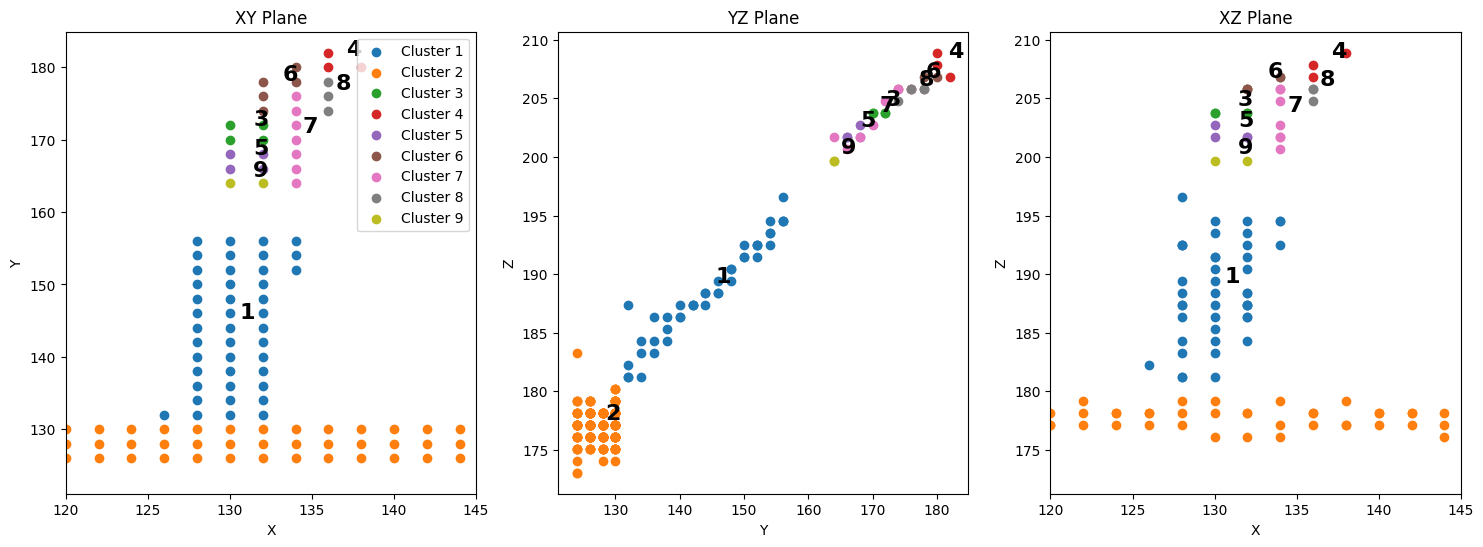

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the .npy file
data = np.load('figure_3.npy')

# Extract columns for clusters, x, y, z
clusters = data[:, 0]
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

# Condition to keep points with z >= 150 and either z <= 200 or (z > 200 and y >= 135)
condition = (z >= 150) & ((z <= 200) | (y >= 135))

# Apply the condition to filter the data
filtered_data = data[condition]

# Remove clusters 3 and 4
filtered_data = filtered_data[~np.isin(filtered_data[:, 0], [3, 4])]

# Reassign new cluster IDs starting from 1
unique_clusters = np.unique(filtered_data[:, 0])
for new_id, old_id in enumerate(unique_clusters, start=1):
    filtered_data[filtered_data[:, 0] == old_id, 0] = new_id

# Save the filtered data into a new file
np.save('filtered_figure_3_with_new_ids.npy', filtered_data)

# Extract columns from the filtered data for clusters, x, y, z
clusters = filtered_data[:, 0]   # cluster labels
x = filtered_data[:, 1]          # x coordinates
y = filtered_data[:, 2]          # y coordinates
z = filtered_data[:, 3]          # z coordinates

# Print the new cluster ID and the number of points in each cluster
unique_clusters = np.unique(clusters)
for cluster in unique_clusters:
    num_points = np.sum(clusters == cluster)
    print(f'Cluster {int(cluster)} has {num_points} points.')

# Define a colormap
cmap = plt.colormaps.get_cmap('tab10')

# Create the figure and subplots with increased size
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Increased figure size

# Scatter plot for xy plane
for idx, cluster in enumerate(unique_clusters):
    mask = clusters == cluster
    axes[0].scatter(x[mask], y[mask], label=f'Cluster {int(cluster)}', color=cmap(idx))
    
    # Calculate mean of x and y for cluster
    mean_x = np.mean(x[mask])
    mean_y = np.mean(y[mask])
    
    # Annotate cluster ID near the mean in the xy plane with an offset
    axes[0].annotate(f'{int(cluster)}', xy=(mean_x, mean_y), 
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=16, fontweight='bold', color='black')

# Set xlim for xy plane
axes[0].set_xlim(120, 145)
axes[0].set_title('XY Plane')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Scatter plot for yz plane
for idx, cluster in enumerate(unique_clusters):
    mask = clusters == cluster
    axes[1].scatter(y[mask], z[mask], label=f'Cluster {int(cluster)}', color=cmap(idx))
    
    # Calculate mean of y and z for cluster
    mean_y = np.mean(y[mask])
    mean_z = np.mean(z[mask])
    
    # Annotate cluster ID near the mean in the yz plane with an offset
    axes[1].annotate(f'{int(cluster)}', xy=(mean_y, mean_z), 
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=16, fontweight='bold', color='black')

axes[1].set_title('YZ Plane')
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Z')

# Scatter plot for xz plane
for idx, cluster in enumerate(unique_clusters):
    mask = clusters == cluster
    axes[2].scatter(x[mask], z[mask], label=f'Cluster {int(cluster)}', color=cmap(idx))
    
    # Calculate mean of x and z for cluster
    mean_x = np.mean(x[mask])
    mean_z = np.mean(z[mask])
    
    # Annotate cluster ID near the mean in the xz plane with an offset
    axes[2].annotate(f'{int(cluster)}', xy=(mean_x, mean_z), 
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=16, fontweight='bold', color='black')

# Set xlim for xz plane
axes[2].set_xlim(120, 145)
axes[2].set_title('XZ Plane')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Z')

# Add legend to the first plot
axes[0].legend(loc='upper right')

# Show the plot with adjusted layout
# plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust margins to avoid tight layout issues
plt.show()


In [28]:
filtered_data

array([[  1.        , 134.        , 156.        , 194.55999756],
       [  1.        , 128.        , 156.        , 196.60800171],
       [  1.        , 132.        , 156.        , 194.55999756],
       ...,
       [  8.        , 136.        , 174.        , 204.80000305],
       [  9.        , 132.        , 164.        , 199.67999268],
       [  9.        , 130.        , 164.        , 199.67999268]])

<u>**Continue Reading**</u>

In the figure above, the cluster labels are marked as text. Now, we attempt to calculate two distances (1) Euclidean  $\sqrt{{(x_{n}-\bar{x_{i}}})^T(x_{n}-\bar{x_{i}}})$ and (2) Mahalanobis $\sqrt{{(x_{n}-\bar{x_{i}}})^TC^{-1}(x_{n}-\bar{x_{i}}})$. This way we can visualize the effect of normalizing the euclidean distance by the covariance matrix. 


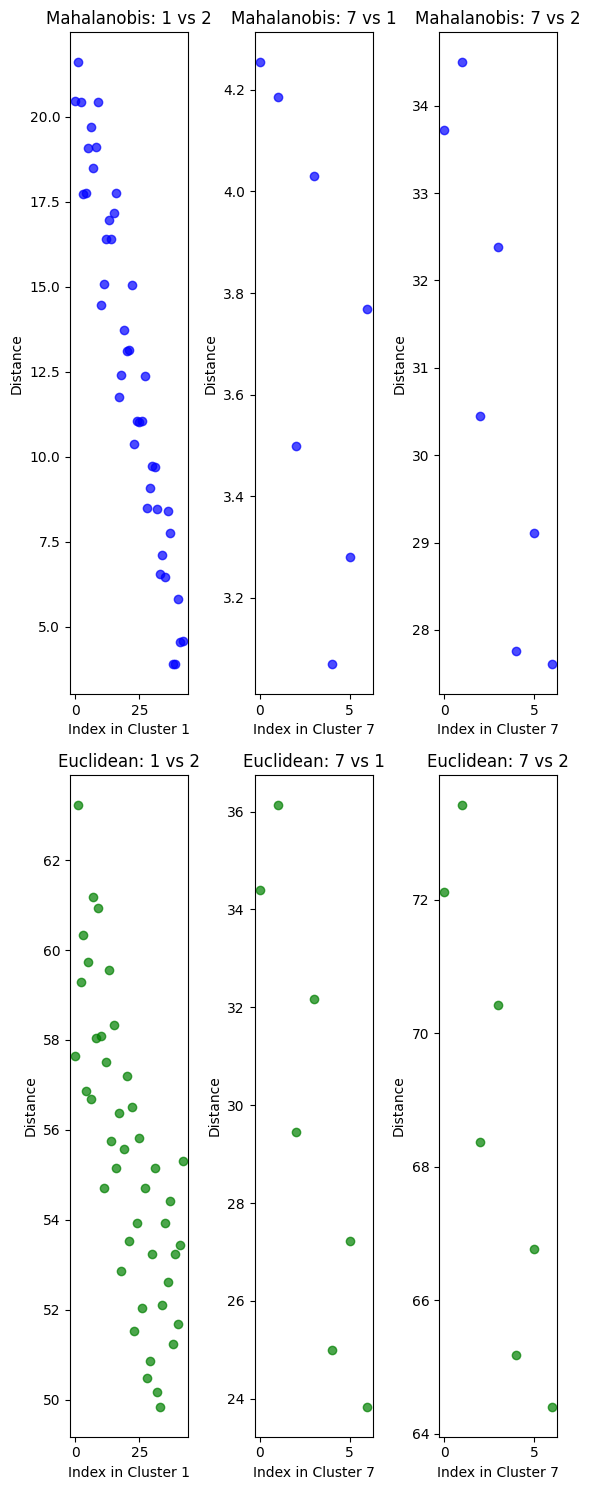

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the .npy file
data = filtered_data

# Extract columns for clusters, x, y, z
clusters = data[:, 0]   # cluster labels
xyz_data = data[:, 1:4]  # [x, y, z] coordinates

# Define the pairs of clusters to analyze
pairs = [(1, 2), (7, 1), (7, 2)]

# Prepare the figure for the plots
plt.figure(figsize=(15, 15))

for idx, (cluster_a, cluster_b) in enumerate(pairs, start=1):
    # Get the data points for the clusters
    cluster_a_data = xyz_data[clusters == cluster_a]
    cluster_b_data = xyz_data[clusters == cluster_b]

    # Print shapes and contents of the clusters
#     print(f'Cluster {cluster_a}: Shape = {cluster_a_data.shape}, Data = {cluster_a_data}')
#     print(f'Cluster {cluster_b}: Shape = {cluster_b_data.shape}, Data = {cluster_b_data}')

    # Check if cluster_b_data has enough unique points
    if cluster_b_data.shape[0] < 2:
        print(f'Skipping pair ({cluster_a}, {cluster_b}) due to insufficient data in cluster {cluster_b}.')
        continue

    # Calculate the mean vector for the reference cluster (cluster B)
    mean_b = np.mean(cluster_b_data, axis=0)

    # Calculate the covariance matrix for cluster B 
    cov_matrix = np.cov(cluster_b_data.T) 
    inv_cov_matrix = np.linalg.inv(cov_matrix)

    # Calculate the Mahalanobis distances for points in cluster A against the mean of cluster B
    mahalanobis_distances = []
    for point in cluster_a_data:
        diff = point - mean_b
        mahalanobis_distance = np.sqrt(diff @ inv_cov_matrix @ diff.T)
        mahalanobis_distances.append(mahalanobis_distance)

    # Calculate the Euclidean distances for points in cluster A against the mean of cluster B
    euclidean_distances = []
    for point in cluster_a_data:
        diff = point - mean_b
        euclidean_distance = np.sqrt(diff @ diff.T)
        euclidean_distances.append(euclidean_distance)

    # Plotting Mahalanobis Distance
    plt.subplot(2, 8, idx)
    plt.scatter(range(len(mahalanobis_distances)), mahalanobis_distances, color='blue', alpha=0.7)
    plt.title(f'Mahalanobis: {cluster_a} vs {cluster_b}')
    plt.xlabel('Index in Cluster ' + str(cluster_a))
    plt.ylabel('Distance')

    # Plotting Euclidean Distance
    plt.subplot(2, 8, idx + 8)
    plt.scatter(range(len(euclidean_distances)), euclidean_distances, color='green', alpha=0.7)
    plt.title(f'Euclidean: {cluster_a} vs {cluster_b}')
    plt.xlabel('Index in Cluster ' + str(cluster_a))
    plt.ylabel('Distance')

# Show the plot
plt.tight_layout()
plt.show()



We will illustrate the regularization using the reduction matrix. 


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the .npy file
data = np.load('figure_3.npy')

# Extract columns for clusters, x, y, z
clusters = data[:, 0]
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

# Condition to keep points with z >= 150 and either z <= 200 or (z > 200 and y >= 135)
condition = (z >= 150) & ((z <= 200) | (y >= 135))

# Apply the condition to filter the data
filtered_data = data[condition]

# Remove clusters 3 and 4
filtered_data = filtered_data[~np.isin(filtered_data[:, 0], [3, 4])]

# Reassign new cluster IDs starting from 1
unique_clusters = np.unique(filtered_data[:, 0])
for new_id, old_id in enumerate(unique_clusters, start=1):
    filtered_data[filtered_data[:, 0] == old_id, 0] = new_id

# Save the filtered data into a new file
np.save('filtered_figure_3_with_new_ids.npy', filtered_data)

# Extract columns from the filtered data for clusters, x, y, z
clusters = filtered_data[:, 0]   # cluster labels
x = filtered_data[:, 1]          # x coordinates
y = filtered_data[:, 2]          # y coordinates
z = filtered_data[:, 3]          # z coordinates

# Print the new cluster ID and the number of points in each cluster
unique_clusters = np.unique(clusters)
for cluster in unique_clusters:
    num_points = np.sum(clusters == cluster)
    print(f'Cluster {int(cluster)} has {num_points} points.')
    


Cluster 1 has 43 points.
Cluster 2 has 237 points.
Cluster 3 has 4 points.
Cluster 4 has 3 points.
Cluster 5 has 4 points.
Cluster 6 has 5 points.
Cluster 7 has 7 points.
Cluster 8 has 3 points.
Cluster 9 has 2 points.


<u>**Continue Reading**</u>

Look at cluster pairs 7,1 and 7,2. Although 7 is twice as distant from 2 as it is from 1, its mahalanobis distance is almost ten times as distant from 2 as it is from 1. 

This is because in dimension X, cluster 2 has large variance, so deviations from mean in X contribute to a lower mahalanobis distance and in dimension Y, has lower variance so deviations from mean in Y contribute to higher mahalanobis distance. This is the net effect of normalizing the euclidean distance by the covariance matrix. Next I use the p value based on this distance to calculate the likelihood of points in cluster j belonging to cluster i. I use a threshold value ($p_{ij}$) of 0.1 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Load the data from the .npy file
data = filtered_data

# Extract columns for clusters, x, y, z
clusters = data[:, 0]   # cluster labels
xyz_data = data[:, 1:4]  # [x, y, z] coordinates

print(np.unique(clusters))

# Define the pairs of clusters to analyze
pairs = [(1, 2), (7, 1), (7, 2)]

for idx, (cluster_a, cluster_b) in enumerate(pairs, start=1):
    # Get the data points for the clusters
    cluster_a_data = xyz_data[clusters == cluster_a]
    cluster_b_data = xyz_data[clusters == cluster_b]

    # Check if cluster_b_data has enough unique points
    if cluster_b_data.shape[0] < 2:
        print(f'Skipping pair ({cluster_a}, {cluster_b}) due to insufficient data in cluster {cluster_b}.')
        continue

    # Calculate the mean vector for the reference cluster (cluster B)
    mean_b = np.mean(cluster_b_data, axis=0)

    # Calculate the covariance matrix for cluster B 
    cov_matrix = np.cov(cluster_b_data.T) 
    inv_cov_matrix = np.linalg.inv(cov_matrix)

    # Calculate the Mahalanobis distances for points in cluster A against the mean of cluster B
    mahalanobis_distances = []
    for point in cluster_a_data:
        diff = point - mean_b
        mahalanobis_distance = np.sqrt(diff @ inv_cov_matrix @ diff.T)
        mahalanobis_distances.append(mahalanobis_distance)

    # Calculate the Euclidean distances for points in cluster A against the mean of cluster B
    euclidean_distances = []
    for point in cluster_a_data:
        diff = point - mean_b
        euclidean_distance = np.sqrt(diff @ diff.T)
        euclidean_distances.append(euclidean_distance)


    # Print the averages and p-values
    avg_mahalanobis = np.mean(mahalanobis_distances)
    avg_euclidean = np.mean(euclidean_distances)
    # Calculate and print the p-values for Mahalanobis distances
    dof = 2  # Degrees of freedom (3 dimensions: x, y, z)
    p_value = 1 - chi2.cdf(avg_mahalanobis, df=dof)  # Survival function (1 - CDF)
    avg_p_value = p_value
    
    print(f'Pair ({cluster_a}, {cluster_b}):')
    print(f'  Average Mahalanobis distance: {avg_mahalanobis:.3f}')
    print(f'  Average Euclidean distance: {avg_euclidean:.3f}')
    print(f'  Chi Square: {chi2.cdf(avg_mahalanobis, df=dof) :.3f}')
    print(f'  p-value (Mahalanobis): {avg_p_value:.3f}')

   

[2. 9.]
Pair (1, 2):
  Average Mahalanobis distance: nan
  Average Euclidean distance: nan
  Chi Square: nan
  p-value (Mahalanobis): nan
Skipping pair (7, 1) due to insufficient data in cluster 1.
Pair (7, 2):
  Average Mahalanobis distance: nan
  Average Euclidean distance: nan
  Chi Square: nan
  p-value (Mahalanobis): nan


C:\Users\alarokia\AppData\Local\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\alarokia\AppData\Local\anaconda3\Lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Singular covariance matrix encountered for clusters (3.0, 4.0). Setting G[2,3] and G[3,2] to 0.
Singular covariance matrix encountered for clusters (3.0, 5.0). Setting G[2,4] and G[4,2] to 0.
Singular covariance matrix encountered for clusters (7.0, 3.0). Setting G[2,6] and G[6,2] to 0.
Singular covariance matrix encountered for clusters (3.0, 8.0). Setting G[2,7] and G[7,2] to 0.
Singular covariance matrix encountered for clusters (3.0, 9.0). Setting G[2,8] and G[8,2] to 0.
Singular covariance matrix encountered for clusters (7.0, 4.0). Setting G[3,6] and G[6,3] to 0.
Singular covariance matrix encountered for clusters (4.0, 8.0). Setting G[3,7] and G[7,3] to 0.
Singular covariance matrix encountered for clusters (4.0, 9.0). Setting G[3,8] and G[8,3] to 0.
Singular covariance matrix encountered for clusters (7.0, 5.0). Setting G[4,6] and G[6,4] to 0.
Singular covariance matrix encountered for clusters (7.0, 6.0). Setting G[5,6] and G[6,5] to 0.
Singular covariance matrix encountered f

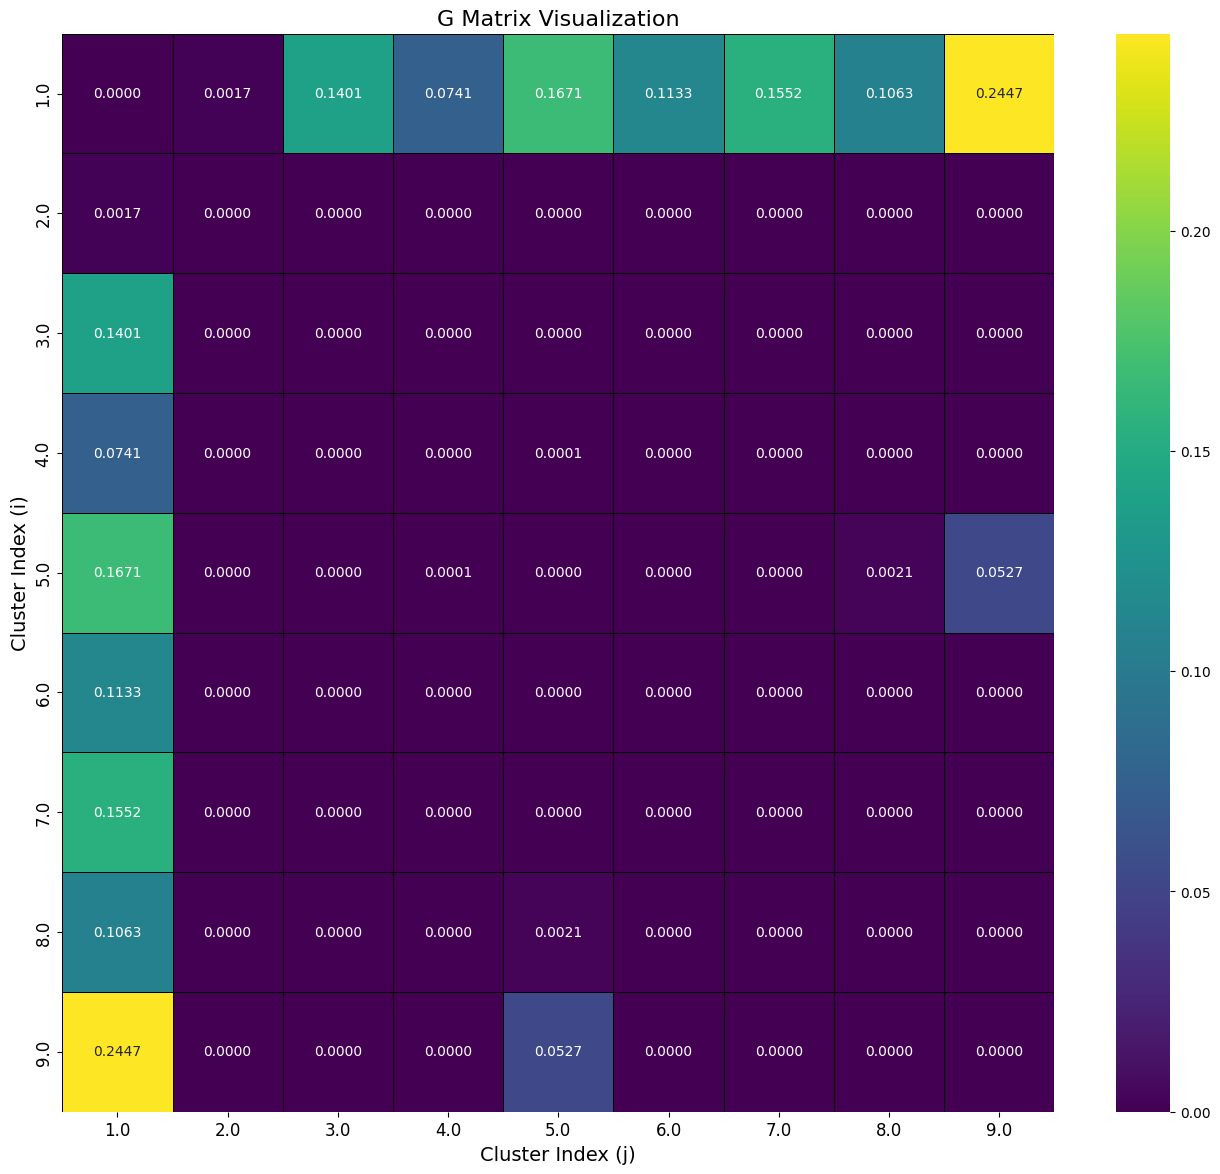

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

# Load the data from the .npy file
data = filtered_data

# Extract clusters and coordinates
clusters = data[:, 0]  # cluster labels
xyz_data = data[:, 1:4]  # [x, y, z] coordinates

# Get unique clusters
unique_clusters = np.unique(clusters)
K = len(unique_clusters)

# Initialize the G matrix
G = np.zeros((K, K))

# Calculate means and covariances for each cluster
means = {}
cov_matrices = {}
counts = {}

for cluster in unique_clusters:
    cluster_data = xyz_data[clusters == cluster]
    means[cluster] = np.mean(cluster_data, axis=0)
    cov_matrices[cluster] = np.cov(cluster_data.T)
    counts[cluster] = cluster_data.shape[0]

# Fill the G matrix
for i in range(K):
    for j in range(i + 1, K):  # Only need to calculate upper triangle
        cluster_i = unique_clusters[i]
        cluster_j = unique_clusters[j]
        
        # Decide which cluster to use as reference (the one with more points)
        if counts[cluster_i] > counts[cluster_j]:
            ci, cj = cluster_i, cluster_j  # ci has more points, cj has fewer points
        elif counts[cluster_i] < counts[cluster_j]:
            ci, cj = cluster_j, cluster_i  # cj has more points, ci has fewer points
        else:  # If sizes are equal, pick the cluster with the lower index as reference
            ci, cj = min(cluster_i, cluster_j), max(cluster_i, cluster_j)

        # Calculate the Mahalanobis distances
        data_j = xyz_data[clusters == cj]  # Points from the smaller cluster (cj)
        mean_i = means[ci]  # Mean of the larger cluster (ci)

        try:
            cov_i_inv = np.linalg.inv(cov_matrices[ci])  # Covariance matrix of the larger cluster (ci)
            
            # Compute the distance for each point in cluster j relative to cluster i
            distances = []
            for point in data_j:
                diff = point - mean_i
                mahalanobis_square = diff @ cov_i_inv @ diff.T
                
                # Check for negative Mahalanobis square (to avoid invalid sqrt)
                if mahalanobis_square < 0:
                    mahalanobis_distance = 0
                else:
                    mahalanobis_distance = np.sqrt(mahalanobis_square)

                distances.append(mahalanobis_distance)

            # Calculate the average distance
            avg_distance = np.mean(distances)

            # Check if avg_distance is zero or very small, set p_value accordingly
            if avg_distance <= 0:
                p_value = 0  # Indicating an invalid case
            else:
                # Calculate p-value and round to 4 decimal places
                p_value = 1 - chi2.cdf(avg_distance, df=2)
            
            # Assign the same value to both G[i, j] and G[j, i] to ensure symmetry
            G[i, j] = round(p_value, 4)
            G[j, i] = G[i, j]  # Ensuring symmetry

        except np.linalg.LinAlgError:
            # If the covariance matrix is singular, set the distance to zero
            G[i, j] = 0
            G[j, i] = G[i, j]  # Ensure symmetry here as well
            print(f'Singular covariance matrix encountered for clusters ({ci}, {cj}). Setting G[{i},{j}] and G[{j},{i}] to 0.')

# Set diagonal elements to zero (if not done already)
np.fill_diagonal(G, 0)

# Check for symmetry between p_ij and p_ji
for i in range(K):
    for j in range(i + 1, K):  # Only check upper triangle
        if G[i, j] != G[j, i]:
            print(f"Symmetry mismatch: G[{i}, {j}] = {G[i, j]} but G[{j}, {i}] = {G[j, i]}")

# Visualization of the G matrix using Seaborn for better aesthetics
plt.figure(figsize=(16, 14))  # Increase the figure size
sns.heatmap(G, annot=True, fmt='.4f', cmap='viridis', cbar=True, 
            annot_kws={"size": 10}, linewidths=.5, linecolor='black')

# Set ticks and labels
plt.xticks(ticks=np.arange(K) + 0.5, labels=unique_clusters, fontsize=12)
plt.yticks(ticks=np.arange(K) + 0.5, labels=unique_clusters, fontsize=12)

# Set title and labels
plt.title('G Matrix Visualization', fontsize=16)
plt.xlabel('Cluster Index (j)', fontsize=14)
plt.ylabel('Cluster Index (i)', fontsize=14)

plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

# Load the data from the .npy file
data = filtered_data

# Extract clusters and coordinates
clusters = data[:, 0]  # cluster labels
xyz_data = data[:, 1:4]  # [x, y, z] coordinates

# Get unique clusters
unique_clusters = np.unique(clusters)
K = len(unique_clusters)

# Initialize the G matrix
G = np.zeros((K, K))

# Define threshold
threshold = 0.1

# Calculate means and covariances for each cluster
means = {}
cov_matrices = {}
counts = {}

for cluster in unique_clusters:
    cluster_data = xyz_data[clusters == cluster]
    means[cluster] = np.mean(cluster_data, axis=0)
    cov_matrices[cluster] = np.cov(cluster_data.T)
    counts[cluster] = cluster_data.shape[0]

# Fill the G matrix
for i in range(K):
    for j in range(i + 1, K):  # Only need to calculate upper triangle
        cluster_i = unique_clusters[i]
        cluster_j = unique_clusters[j]
        
        # Decide which cluster to use as reference (the one with more points)
        if counts[cluster_i] > counts[cluster_j]:
            ci, cj = cluster_i, cluster_j  # ci has more points, cj has fewer points
        elif counts[cluster_i] < counts[cluster_j]:
            ci, cj = cluster_j, cluster_i  # cj has more points, ci has fewer points
        else:  # If sizes are equal, pick the cluster with the lower index as reference
            ci, cj = min(cluster_i, cluster_j), max(cluster_i, cluster_j)

        # Calculate the Mahalanobis distances
        data_j = xyz_data[clusters == cj]  # Points from the smaller cluster (cj)
        mean_i = means[ci]  # Mean of the larger cluster (ci)

        try:
            cov_i_inv = np.linalg.inv(cov_matrices[ci])  # Covariance matrix of the larger cluster (ci)
            
            # Compute the distance for each point in cluster j relative to cluster i
            distances = []
            for point in data_j:
                diff = point - mean_i
                mahalanobis_square = diff @ cov_i_inv @ diff.T
                
                # Check for negative Mahalanobis square (to avoid invalid sqrt)
                if mahalanobis_square < 0:
                    mahalanobis_distance = 0
                else:
                    mahalanobis_distance = np.sqrt(mahalanobis_square)

                distances.append(mahalanobis_distance)

            # Calculate the average distance
            avg_distance = np.mean(distances)

            # Check if avg_distance is zero or very small, set p_value accordingly
            if avg_distance <= 0:
                p_value = 0  # Indicating an invalid case
            else:
                # Calculate p-value and round to 4 decimal places
                p_value = 1 - chi2.cdf(avg_distance, df=2)
            
            print(cluster_i, cluster_j, p_value)
            
            # Apply threshold: if p_value is less than 0.1, set G[i, j] to 0
            if p_value < threshold:
                p_value = 0
            
            # Assign the same value to both G[i, j] and G[j, i] to ensure symmetry
            G[i, j] = round(p_value, 4)
            G[j, i] = G[i, j]  # Ensuring symmetry

        except np.linalg.LinAlgError:
            # If the covariance matrix is singular, set the distance to zero
            G[i, j] = 0
            G[j, i] = G[i, j]  # Ensure symmetry here as well
            print(f'Singular covariance matrix encountered for clusters ({ci}, {cj}). Setting G[{i},{j}] and G[{j},{i}] to 0.')

# Set diagonal elements to zero (if not done already)
np.fill_diagonal(G, 0)

# Check for symmetry between p_ij and p_ji
for i in range(K):
    for j in range(i + 1, K):  # Only check upper triangle
        if G[i, j] != G[j, i]:
            print(f"Symmetry mismatch: G[{i}, {j}] = {G[i, j]} but G[{j}, {i}] = {G[j, i]}")

# Visualization of the G matrix using Seaborn for better aesthetics
plt.figure(figsize=(16, 14))  # Increase the figure size
sns.heatmap(G, annot=True, fmt='.4f', cmap='viridis', cbar=True, 
            annot_kws={"size": 10}, linewidths=.5, linecolor='black')

# Set ticks and labels
plt.xticks(ticks=np.arange(K) + 0.5, labels=unique_clusters, fontsize=12)
plt.yticks(ticks=np.arange(K) + 0.5, labels=unique_clusters, fontsize=12)

# Set title and labels
plt.title('G Matrix Visualization', fontsize=16)
plt.xlabel('Cluster Index (j)', fontsize=14)
plt.ylabel('Cluster Index (i)', fontsize=14)

plt.show()


NameError: name 'filtered_data' is not defined

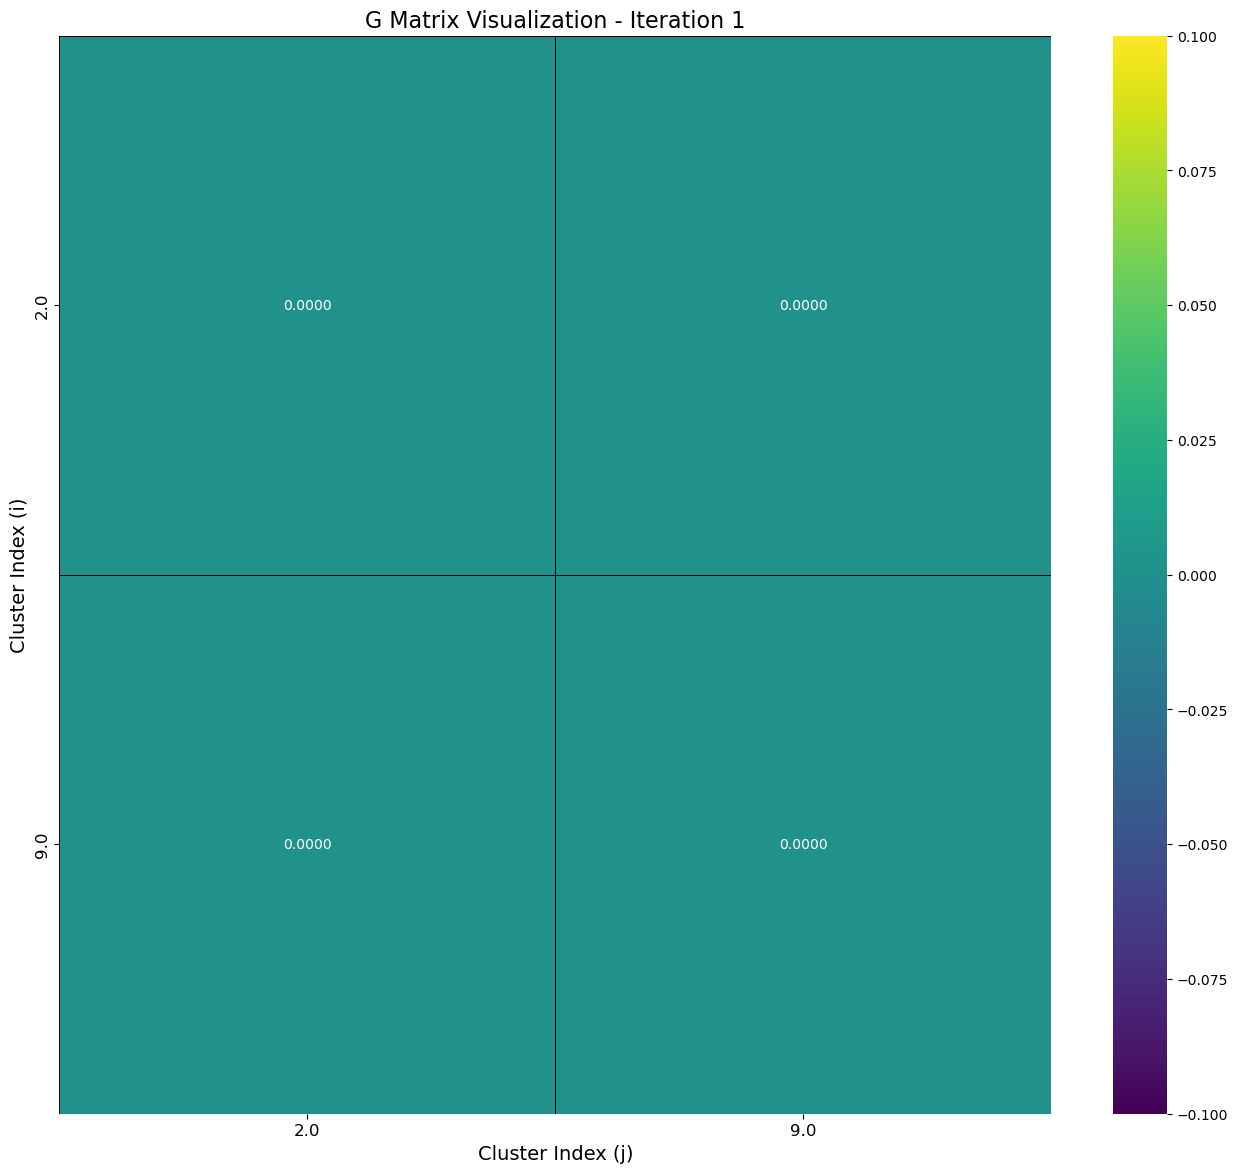

No non-zero elements found. Exiting loop.
Final G matrix:
[[0. 0.]
 [0. 0.]]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
import os

# Load the data from the .npy file
data = filtered_data  # Replace with the actual .npy data loading if needed

# Extract clusters and coordinates
clusters = data[:, 0]  # cluster labels
xyz_data = data[:, 1:4]  # [x, y, z] coordinates

# Get unique clusters
unique_clusters = np.unique(clusters)

# Create a directory to save output if it doesn't exist
output_dir = "cluster_outputs"
os.makedirs(output_dir, exist_ok=True)

def save_clusters(filename, clusters, xyz_data):
    # Combine xyz_data and clusters into one array
    combined_data = np.column_stack((xyz_data, clusters))
    np.save(filename, combined_data)

def calculate_g_matrix(data, clusters, threshold=0.1):
    unique_clusters = np.unique(clusters)
    K = len(unique_clusters)
    
    # Initialize the G matrix
    G = np.zeros((K, K))
    
    # Calculate means and covariances for each cluster
    means = {}
    cov_matrices = {}
    counts = {}
    
    for cluster in unique_clusters:
        cluster_data = xyz_data[clusters == cluster]
        means[cluster] = np.mean(cluster_data, axis=0)
        cov_matrices[cluster] = np.cov(cluster_data.T)
        counts[cluster] = cluster_data.shape[0]
    
    # Fill the G matrix
    for i in range(K):
        for j in range(i + 1, K):  # Only need to calculate upper triangle
            cluster_i = unique_clusters[i]
            cluster_j = unique_clusters[j]
            
            # Decide which cluster to use as reference (the one with more points)
            if counts[cluster_i] > counts[cluster_j]:
                ci, cj = cluster_i, cluster_j
            elif counts[cluster_i] < counts[cluster_j]:
                ci, cj = cluster_j, cluster_i
            else:
                ci, cj = min(cluster_i, cluster_j), max(cluster_i, cluster_j)

            # Calculate the Mahalanobis distances
            data_j = xyz_data[clusters == cj]  # Points from the smaller cluster (cj)
            mean_i = means[ci]  # Mean of the larger cluster (ci)

            try:
                cov_i_inv = np.linalg.inv(cov_matrices[ci])  # Covariance matrix of the larger cluster (ci)
                
                # Compute the distance for each point in cluster j relative to cluster i
                distances = []
                for point in data_j:
                    diff = point - mean_i
                    mahalanobis_square = diff @ cov_i_inv @ diff.T
                    
                    if mahalanobis_square < 0:
                        mahalanobis_distance = 0
                    else:
                        mahalanobis_distance = np.sqrt(mahalanobis_square)

                    distances.append(mahalanobis_distance)

                avg_distance = np.mean(distances)

                if avg_distance <= 0:
                    p_value = 0
                else:
                    p_value = 1 - chi2.cdf(avg_distance, df=2)

                # Apply threshold
                if p_value < threshold:
                    p_value = 0
                
                G[i, j] = round(p_value, 4)
                G[j, i] = G[i, j]  # Ensuring symmetry

            except np.linalg.LinAlgError:
                G[i, j] = 0
                G[j, i] = G[i, j]  # Ensure symmetry here as well
                print(f'Singular covariance matrix encountered for clusters ({ci}, {cj}). Setting G[{i},{j}] and G[{j},{i}] to 0.')

    # Ensure only the maximum value in each column remains non-zero
    for j in range(K):
        non_zero_values = G[:, j][G[:, j] != 0]
        if non_zero_values.size > 0:
            max_value = np.max(non_zero_values)
            for i in range(K):
                if G[i, j] != max_value:
                    G[i, j] = 0
                    G[j, i] = 0

    np.fill_diagonal(G, 0)

    return G

# Save initial clusters
save_clusters(os.path.join(output_dir, 'initial_clusters.npy'), clusters, xyz_data)

# Main merging loop
iteration = 0
while True:
    iteration += 1
    # Calculate the G matrix
    G = calculate_g_matrix(xyz_data, clusters)
    
    # Visualize the G matrix during each iteration
    plt.figure(figsize=(16, 14))  # Increase the figure size
    sns.heatmap(G, annot=True, fmt='.4f', cmap='viridis', cbar=True, 
                annot_kws={"size": 10}, linewidths=.5, linecolor='black')

    plt.xticks(ticks=np.arange(len(unique_clusters)) + 0.5, labels=unique_clusters, fontsize=12)
    plt.yticks(ticks=np.arange(len(unique_clusters)) + 0.5, labels=unique_clusters, fontsize=12)

    plt.title(f'G Matrix Visualization - Iteration {iteration}', fontsize=16)
    plt.xlabel('Cluster Index (j)', fontsize=14)
    plt.ylabel('Cluster Index (i)', fontsize=14)
    plt.show()
    
    # Check for non-zero elements in G to decide whether to merge
    non_zero_indices = np.argwhere(G != 0)
    
    if non_zero_indices.size == 0:  # Exit if no non-zero elements
        print("No non-zero elements found. Exiting loop.")
        break
    
    # Create a mapping for merged clusters
    cluster_mapping = {label: label for label in unique_clusters}

    # Merge clusters for every non-zero element p_{ij}
    for i, j in non_zero_indices:
        if i < j:  # Ensure each pair is only processed once
            print(f"Merging clusters {unique_clusters[i]} and {unique_clusters[j]}.")

            # Merge clusters
            merged_cluster_label = max(unique_clusters[i], unique_clusters[j])  # Keep the higher label for consistency
            combined_data = np.concatenate((xyz_data[clusters == unique_clusters[i]], 
                                             xyz_data[clusters == unique_clusters[j]]))
            
            # Update cluster labels using mapping
            clusters[clusters == unique_clusters[j]] = merged_cluster_label  # Merge cluster j into i
            cluster_mapping[unique_clusters[i]] = merged_cluster_label
            cluster_mapping[unique_clusters[j]] = merged_cluster_label
            
            # Update clusters based on the mapping
            for old_label, new_label in cluster_mapping.items():
                clusters[clusters == old_label] = new_label

            # Update unique_clusters list
            unique_clusters = np.unique(clusters)

    # Save clusters after each iteration
    save_clusters(os.path.join(output_dir, f'clusters_after_iteration_{iteration}.npy'), clusters, xyz_data)

    # Scatter plot of the data points color-coded by their new cluster labels
    plt.figure(figsize=(10, 8))
    for label in unique_clusters:
        cluster_data = xyz_data[clusters == label]
        plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {label}')

        # Calculate mean position for labeling
        mean_position = np.mean(cluster_data, axis=0)
        plt.text(mean_position[0], mean_position[1], str(label), fontsize=12, 
                 ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

    plt.title(f'Scatter Plot of Data Points - Iteration {iteration}', fontsize=16)
    plt.xlabel('X Coordinate', fontsize=14)
    plt.ylabel('Y Coordinate', fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

print("Final G matrix:")
print(G)


Singular covariance matrix encountered for clusters (3.0, 4.0). Setting G[2,3] and G[3,2] to 0.
Singular covariance matrix encountered for clusters (3.0, 5.0). Setting G[2,4] and G[4,2] to 0.
Singular covariance matrix encountered for clusters (7.0, 3.0). Setting G[2,6] and G[6,2] to 0.
Singular covariance matrix encountered for clusters (3.0, 8.0). Setting G[2,7] and G[7,2] to 0.
Singular covariance matrix encountered for clusters (3.0, 9.0). Setting G[2,8] and G[8,2] to 0.
Singular covariance matrix encountered for clusters (7.0, 4.0). Setting G[3,6] and G[6,3] to 0.
Singular covariance matrix encountered for clusters (7.0, 5.0). Setting G[4,6] and G[6,4] to 0.
Singular covariance matrix encountered for clusters (7.0, 6.0). Setting G[5,6] and G[6,5] to 0.
Singular covariance matrix encountered for clusters (7.0, 8.0). Setting G[6,7] and G[7,6] to 0.
Singular covariance matrix encountered for clusters (7.0, 9.0). Setting G[6,8] and G[8,6] to 0.
Singular covariance matrix encountered f

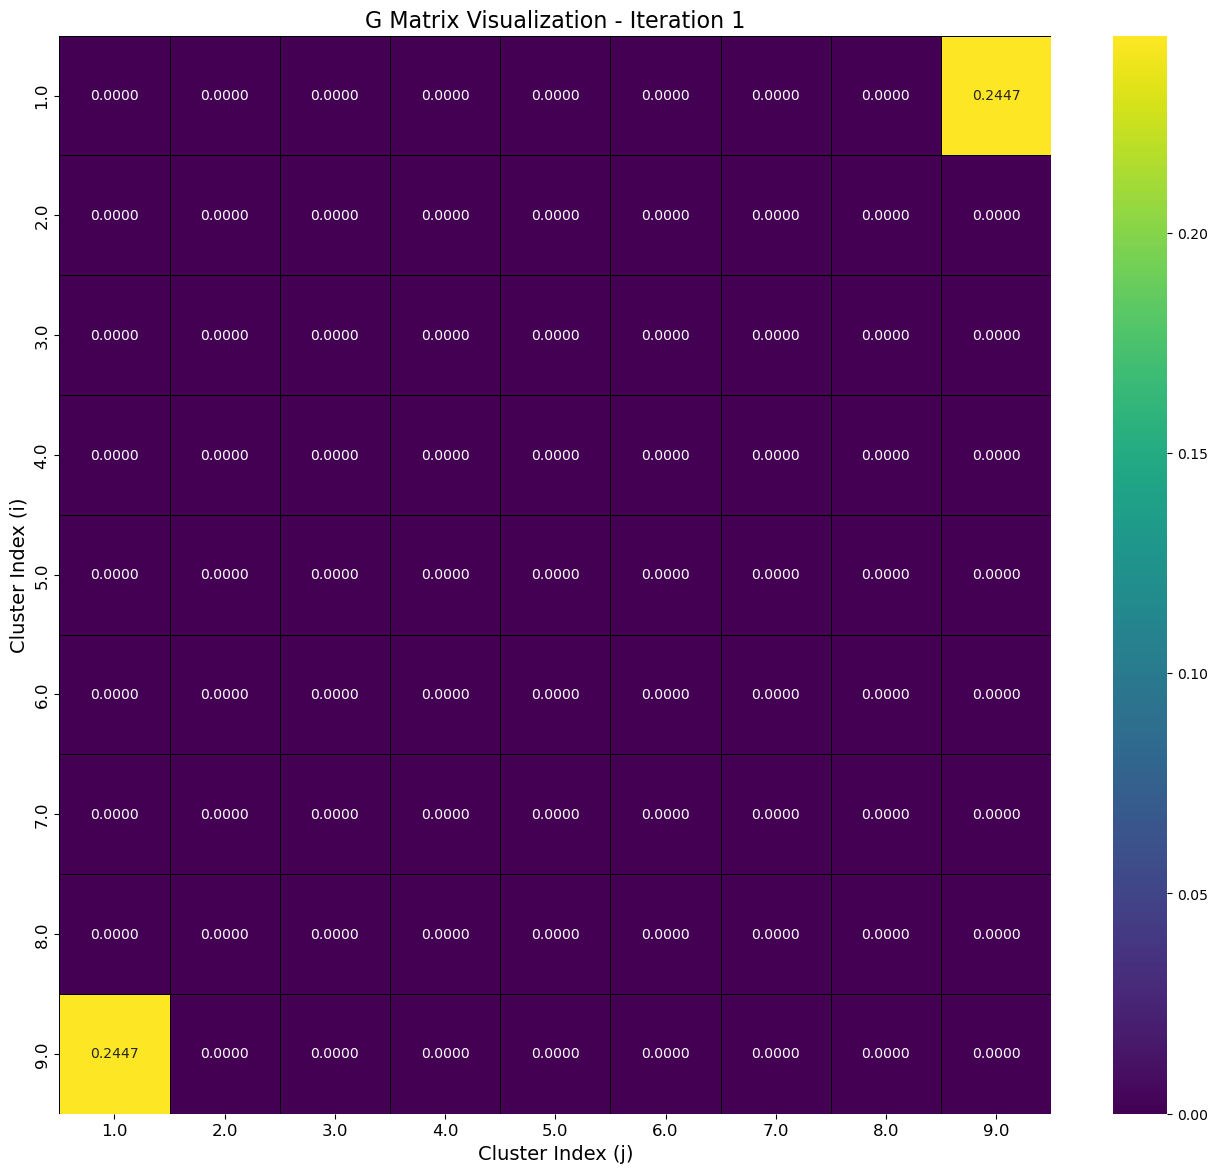

Merging clusters 1.0 and 9.0.


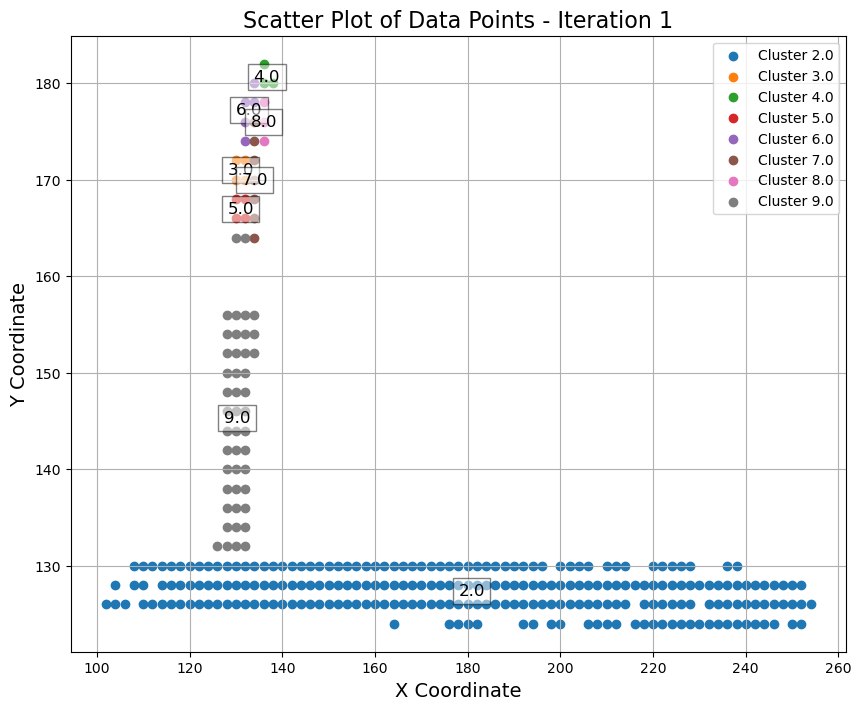

Singular covariance matrix encountered for clusters (3.0, 4.0). Setting G[1,2] and G[2,1] to 0.
Singular covariance matrix encountered for clusters (3.0, 5.0). Setting G[1,3] and G[3,1] to 0.
Singular covariance matrix encountered for clusters (7.0, 3.0). Setting G[1,5] and G[5,1] to 0.
Singular covariance matrix encountered for clusters (3.0, 8.0). Setting G[1,6] and G[6,1] to 0.
Singular covariance matrix encountered for clusters (7.0, 4.0). Setting G[2,5] and G[5,2] to 0.
Singular covariance matrix encountered for clusters (7.0, 5.0). Setting G[3,5] and G[5,3] to 0.
Singular covariance matrix encountered for clusters (7.0, 6.0). Setting G[4,5] and G[5,4] to 0.
Singular covariance matrix encountered for clusters (7.0, 8.0). Setting G[5,6] and G[6,5] to 0.


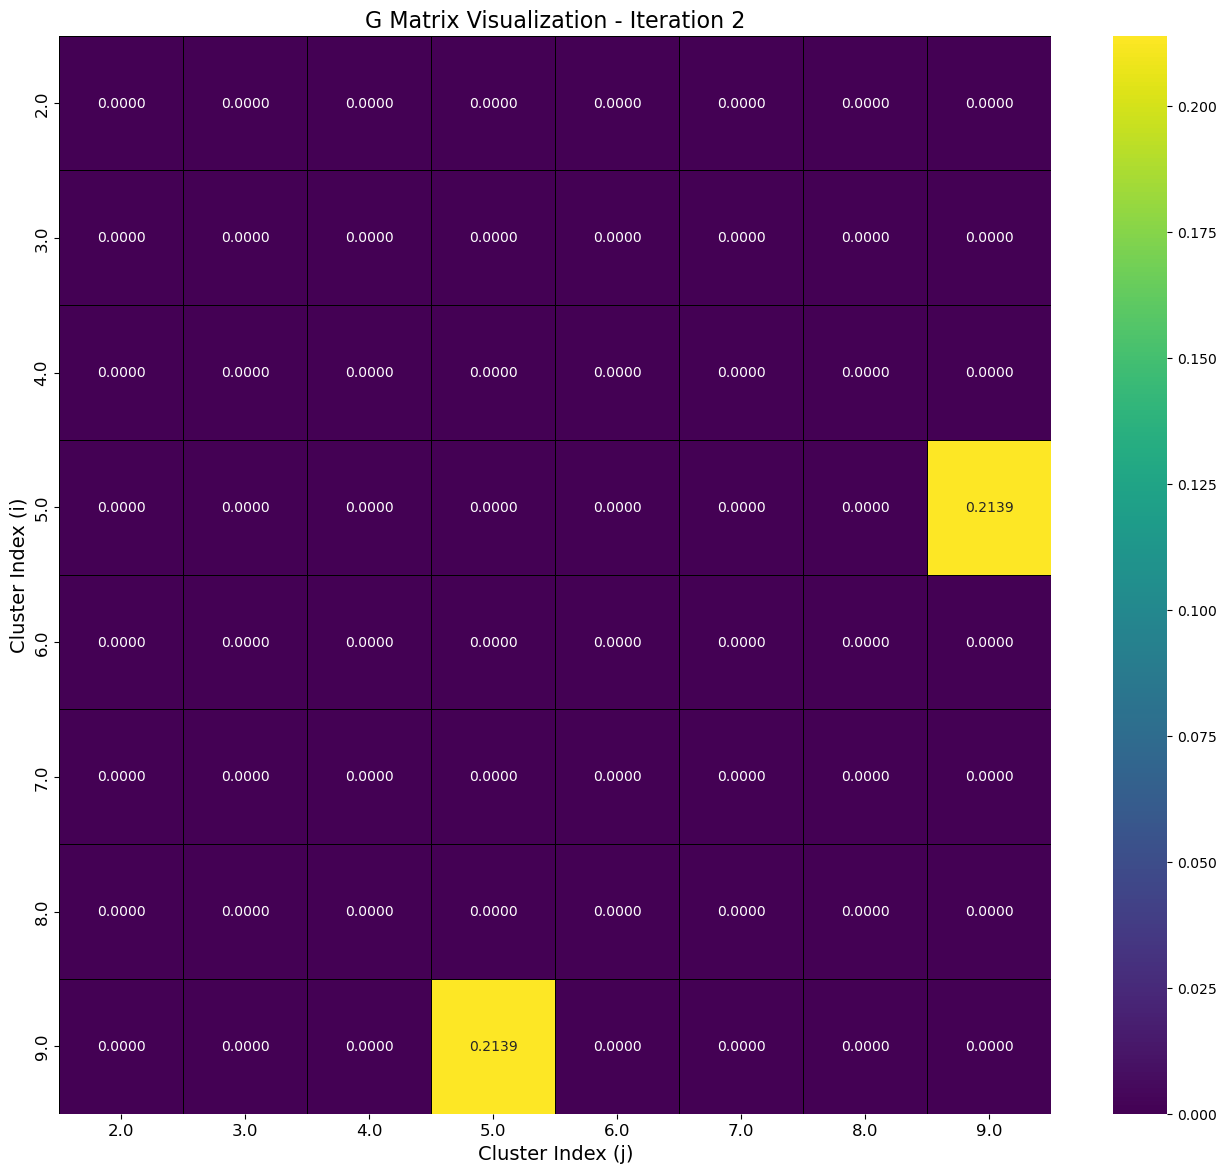

Merging clusters 5.0 and 9.0.


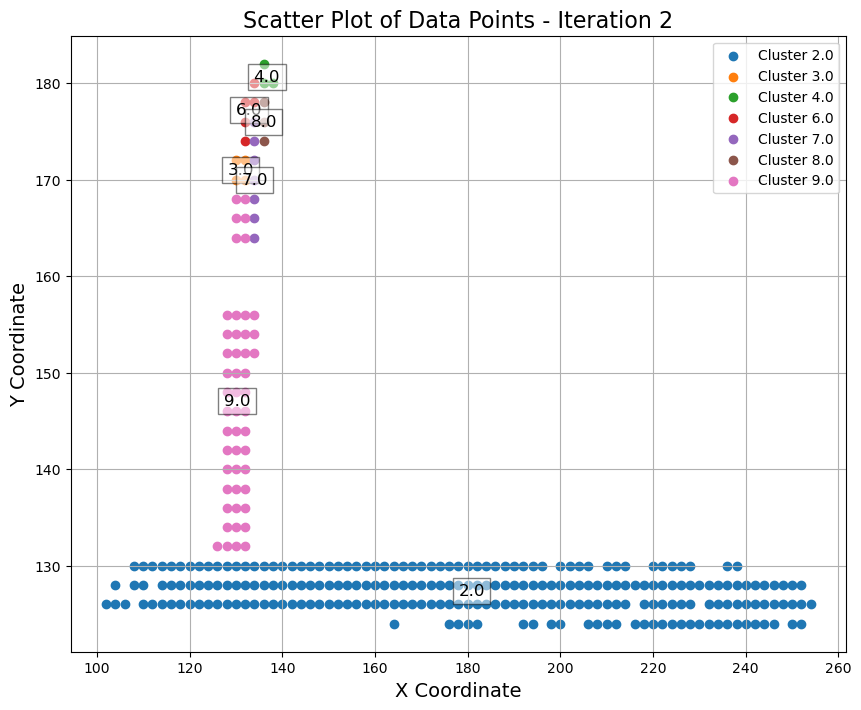

Singular covariance matrix encountered for clusters (3.0, 4.0). Setting G[1,2] and G[2,1] to 0.
Singular covariance matrix encountered for clusters (7.0, 3.0). Setting G[1,4] and G[4,1] to 0.
Singular covariance matrix encountered for clusters (3.0, 8.0). Setting G[1,5] and G[5,1] to 0.
Singular covariance matrix encountered for clusters (7.0, 4.0). Setting G[2,4] and G[4,2] to 0.
Singular covariance matrix encountered for clusters (7.0, 6.0). Setting G[3,4] and G[4,3] to 0.
Singular covariance matrix encountered for clusters (7.0, 8.0). Setting G[4,5] and G[5,4] to 0.


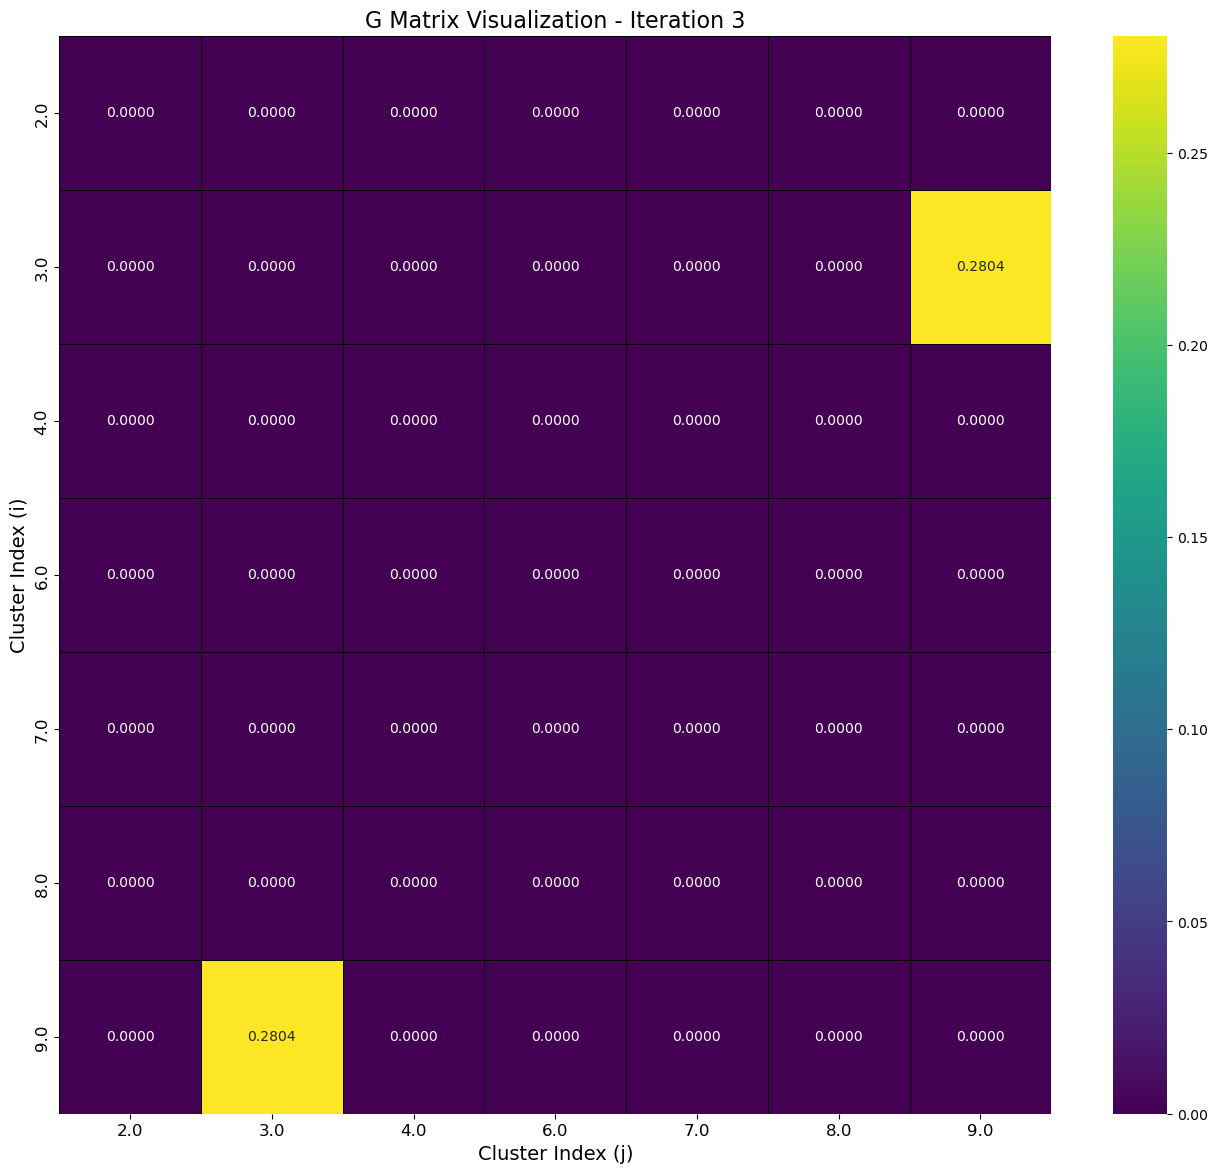

Merging clusters 3.0 and 9.0.


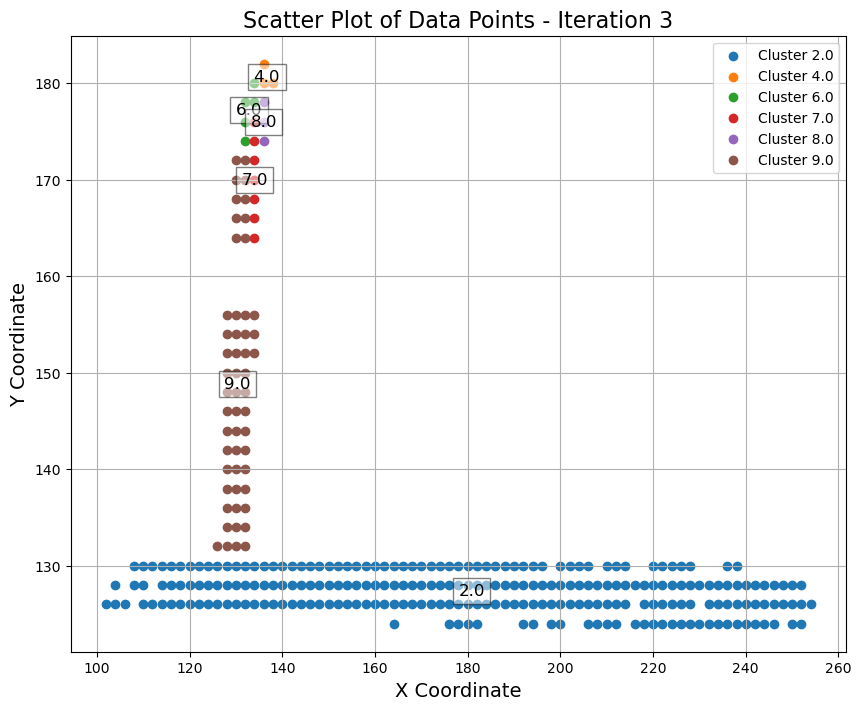

Singular covariance matrix encountered for clusters (7.0, 4.0). Setting G[1,3] and G[3,1] to 0.
Singular covariance matrix encountered for clusters (7.0, 6.0). Setting G[2,3] and G[3,2] to 0.
Singular covariance matrix encountered for clusters (7.0, 8.0). Setting G[3,4] and G[4,3] to 0.


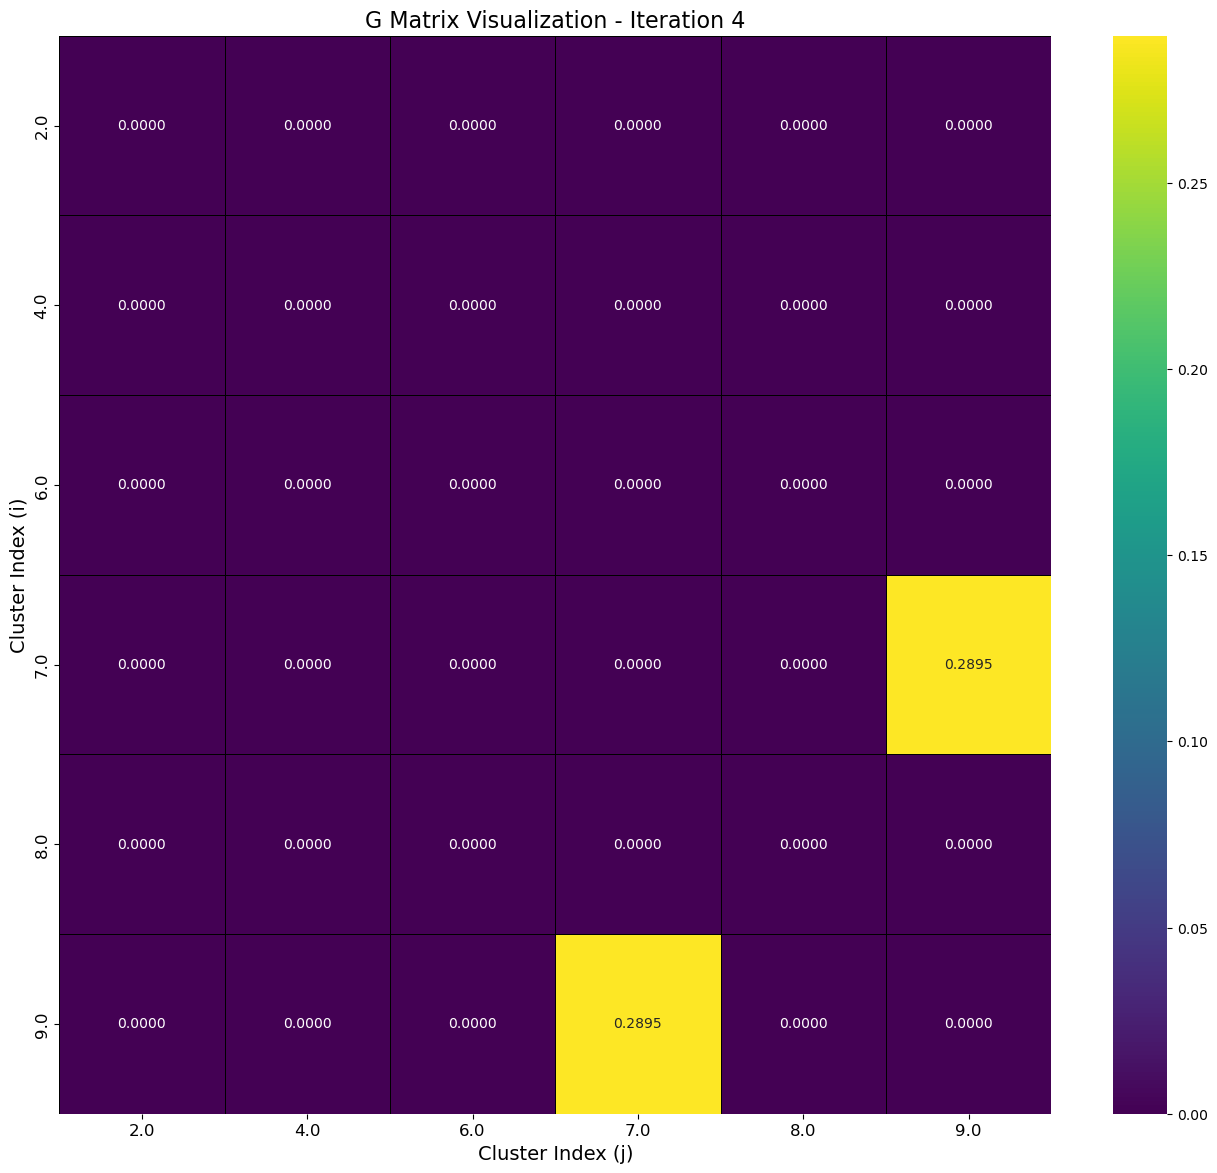

Merging clusters 7.0 and 9.0.


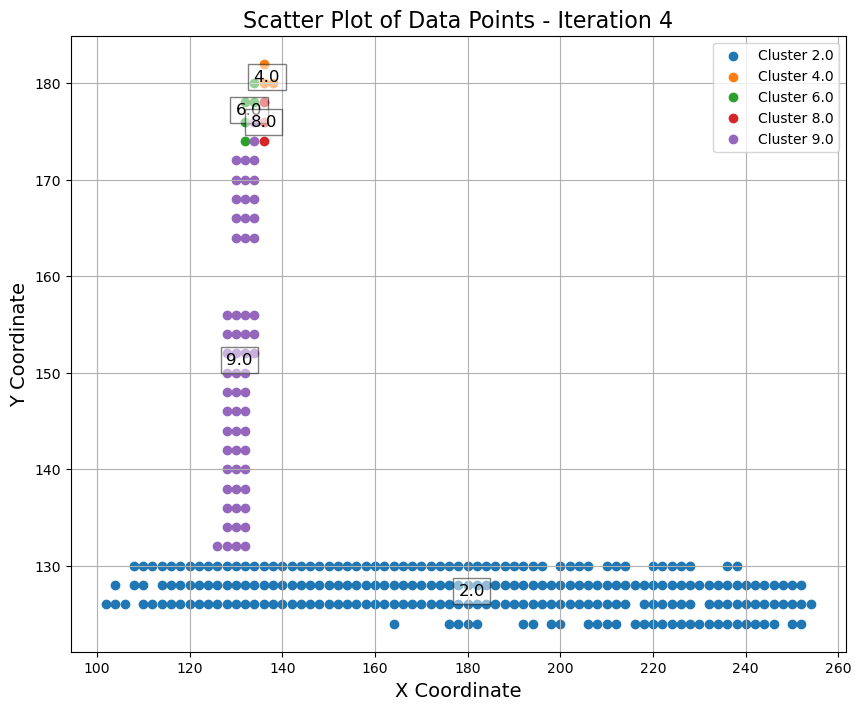

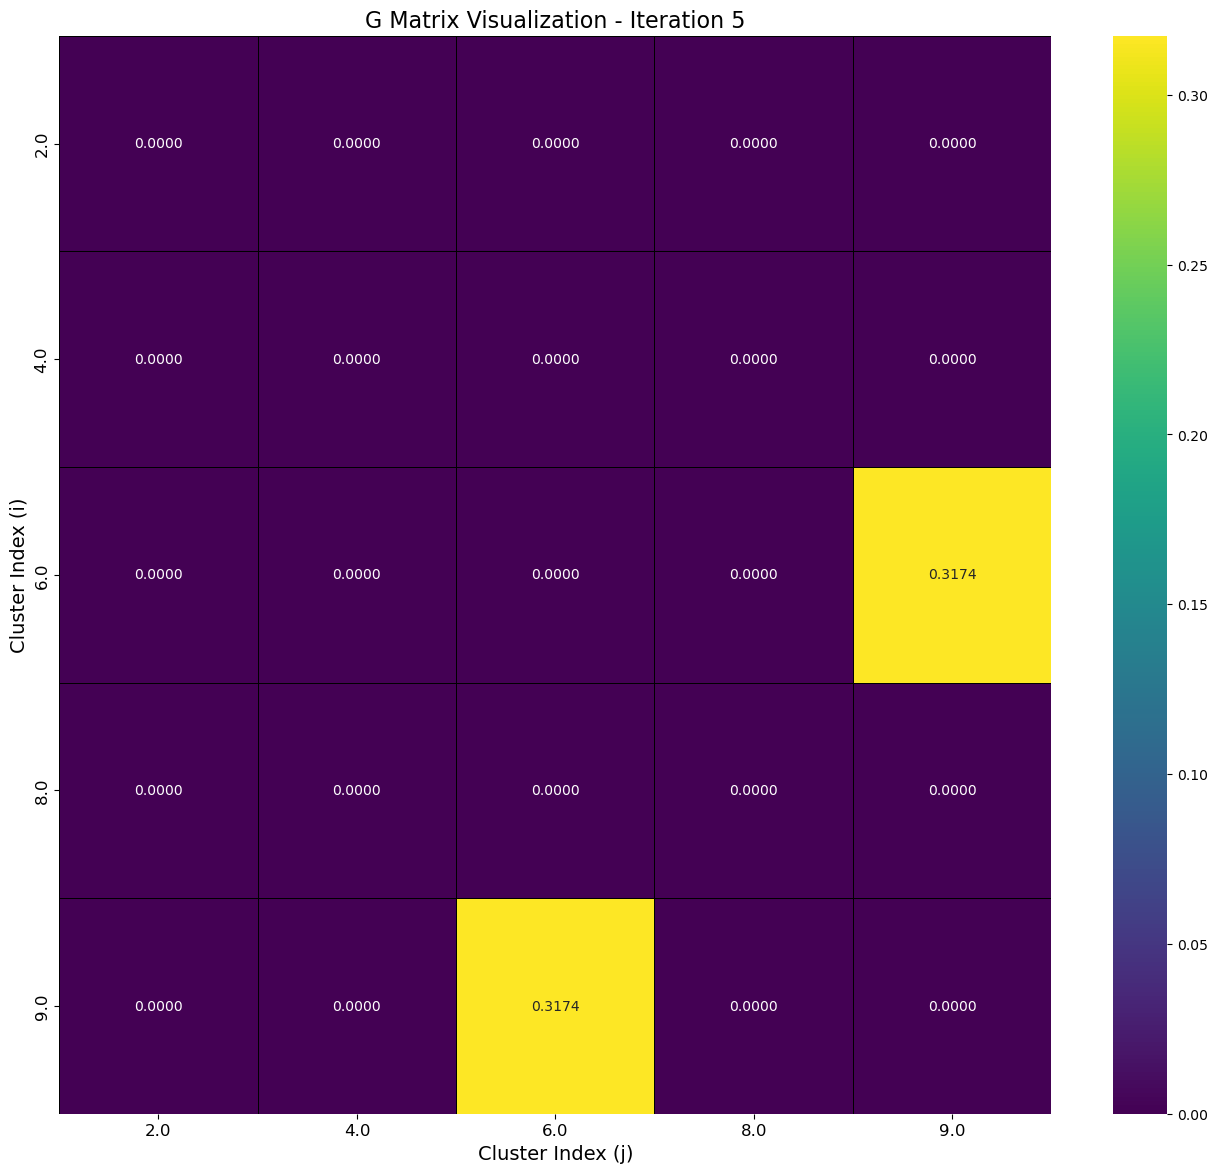

Merging clusters 6.0 and 9.0.


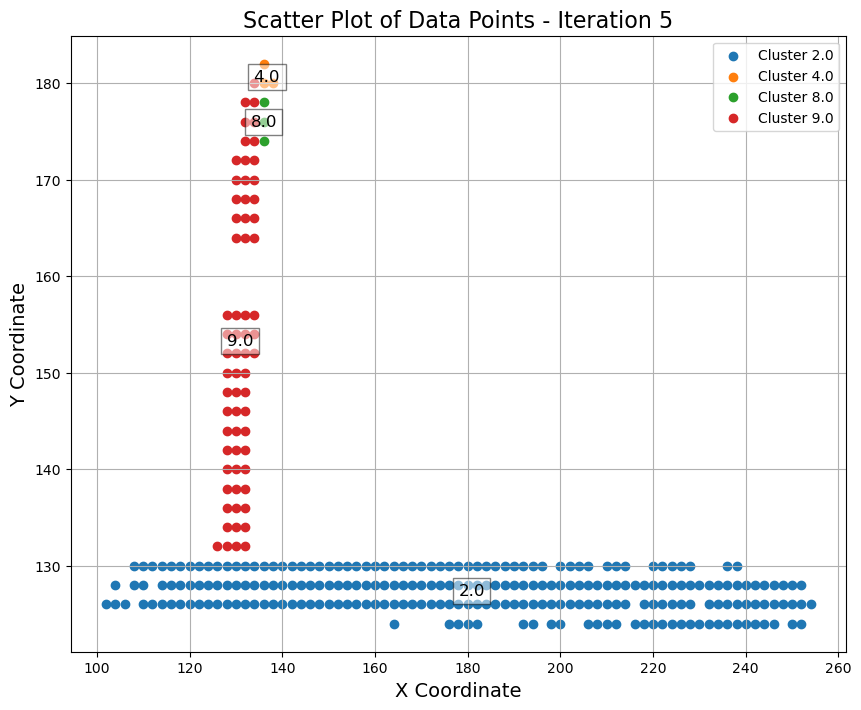

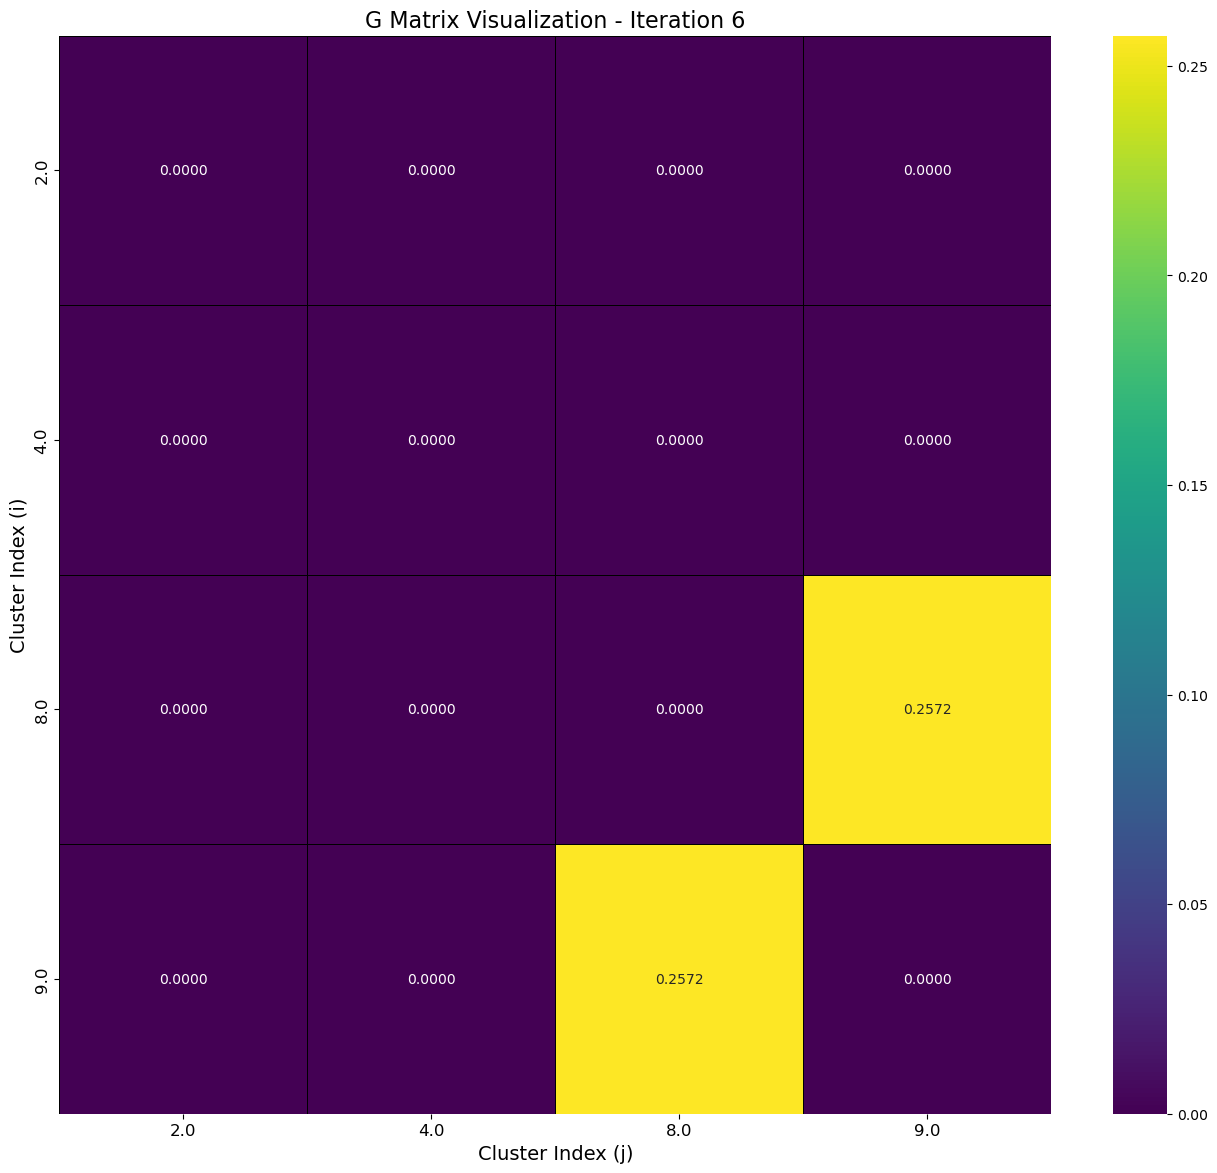

Merging clusters 8.0 and 9.0.


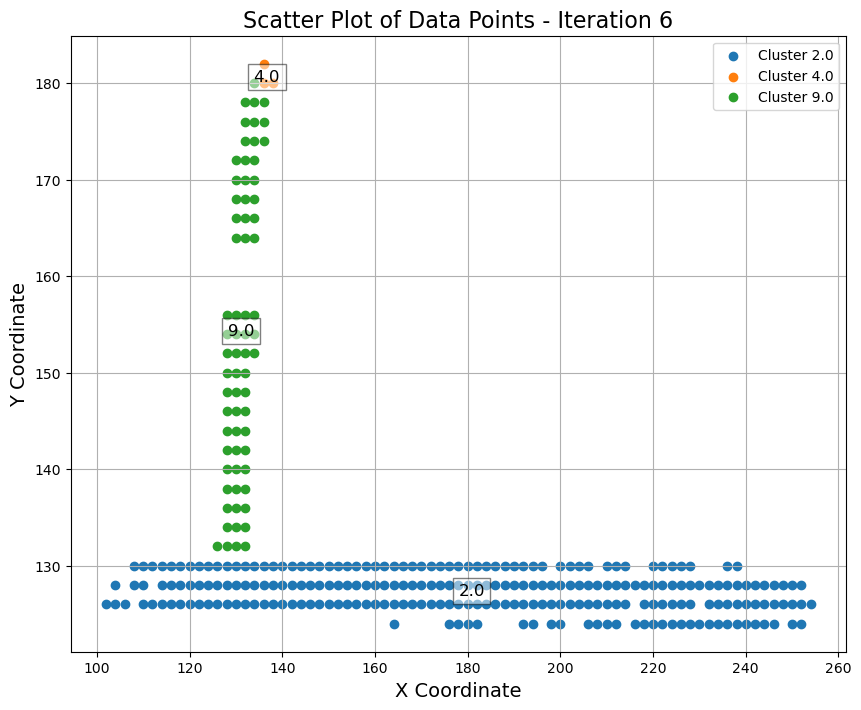

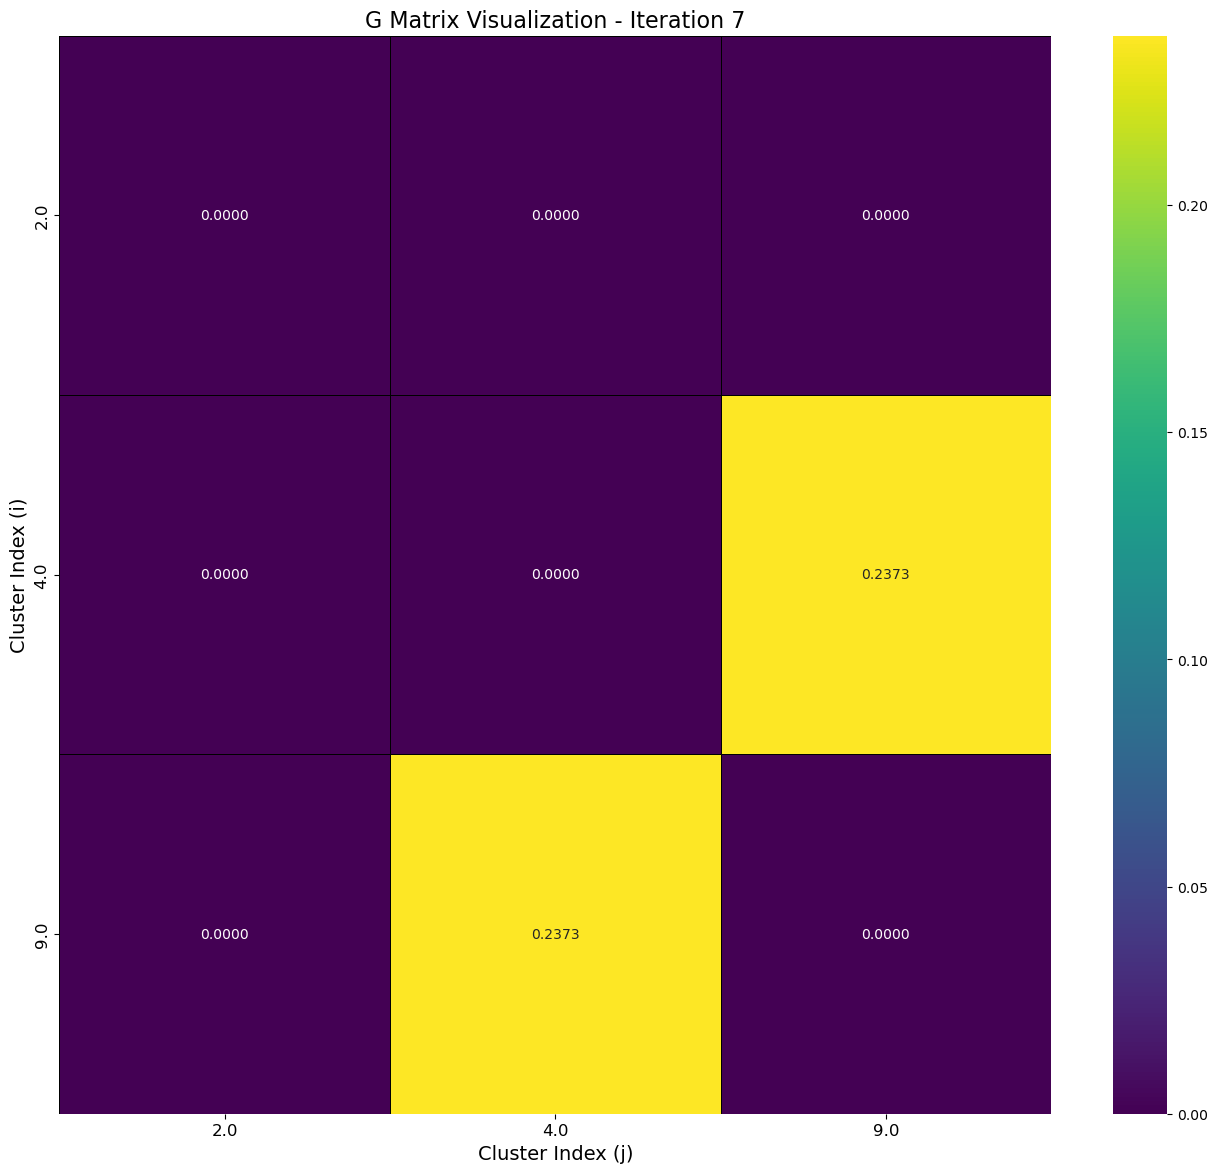

Merging clusters 4.0 and 9.0.


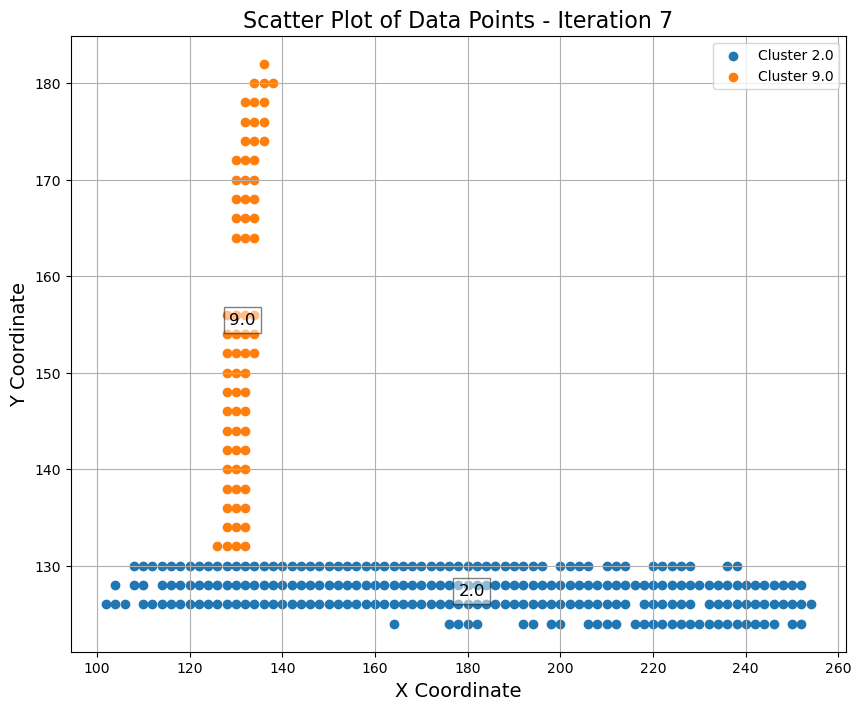

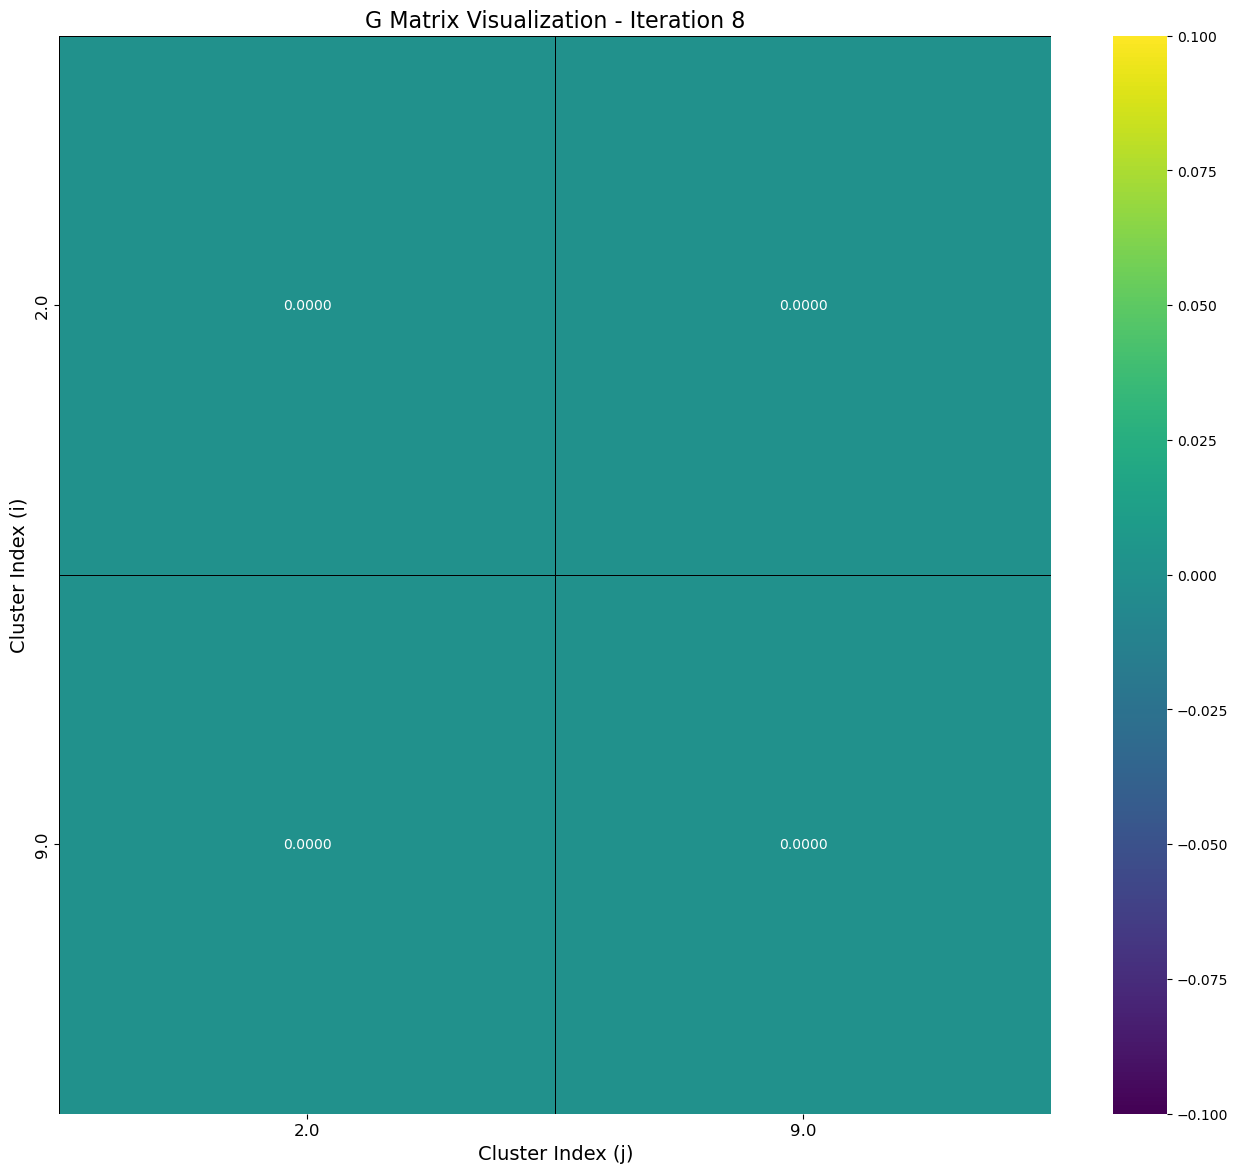

No non-zero elements found. Exiting loop.
Final G matrix:
[[0. 0.]
 [0. 0.]]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

# Load the data from the .npy file
data = filtered_data  # Replace with the actual .npy data loading if needed

# Extract clusters and coordinates
clusters = data[:, 0]  # cluster labels
xyz_data = data[:, 1:4]  # [x, y, z] coordinates

# Get unique clusters
unique_clusters = np.unique(clusters)

def calculate_g_matrix(data, clusters, threshold=0.1):
    unique_clusters = np.unique(clusters)
    K = len(unique_clusters)
    
    # Initialize the G matrix
    G = np.zeros((K, K))
    
    # Calculate means and covariances for each cluster
    means = {}
    cov_matrices = {}
    counts = {}
    
    for cluster in unique_clusters:
        cluster_data = xyz_data[clusters == cluster]
        means[cluster] = np.mean(cluster_data, axis=0)
        cov_matrices[cluster] = np.cov(cluster_data.T)
        counts[cluster] = cluster_data.shape[0]
    
    # Fill the G matrix
    for i in range(K):
        for j in range(i + 1, K):  # Only need to calculate upper triangle
            cluster_i = unique_clusters[i]
            cluster_j = unique_clusters[j]
            
            # Decide which cluster to use as reference (the one with more points)
            if counts[cluster_i] > counts[cluster_j]:
                ci, cj = cluster_i, cluster_j
            elif counts[cluster_i] < counts[cluster_j]:
                ci, cj = cluster_j, cluster_i
            else:
                ci, cj = min(cluster_i, cluster_j), max(cluster_i, cluster_j)

            # Calculate the Mahalanobis distances
            data_j = xyz_data[clusters == cj]  # Points from the smaller cluster (cj)
            mean_i = means[ci]  # Mean of the larger cluster (ci)

            try:
                cov_i_inv = np.linalg.inv(cov_matrices[ci])  # Covariance matrix of the larger cluster (ci)
                
                # Compute the distance for each point in cluster j relative to cluster i
                distances = []
                for point in data_j:
                    diff = point - mean_i
                    mahalanobis_square = diff @ cov_i_inv @ diff.T
                    
                    if mahalanobis_square < 0:
                        mahalanobis_distance = 0
                    else:
                        mahalanobis_distance = np.sqrt(mahalanobis_square)

                    distances.append(mahalanobis_distance)

                avg_distance = np.mean(distances)

                if avg_distance <= 0:
                    p_value = 0
                else:
                    p_value = 1 - chi2.cdf(avg_distance, df=2)

                # Apply threshold
                if p_value < threshold:
                    p_value = 0
                
                G[i, j] = round(p_value, 4)
                G[j, i] = G[i, j]  # Ensuring symmetry

            except np.linalg.LinAlgError:
                G[i, j] = 0
                G[j, i] = G[i, j]  # Ensure symmetry here as well
                print(f'Singular covariance matrix encountered for clusters ({ci}, {cj}). Setting G[{i},{j}] and G[{j},{i}] to 0.')

    # Ensure only the maximum value in each column remains non-zero
    for j in range(K):
        non_zero_values = G[:, j][G[:, j] != 0]
        if non_zero_values.size > 0:
            max_value = np.max(non_zero_values)
            for i in range(K):
                if G[i, j] != max_value:
                    G[i, j] = 0
                    G[j, i] = 0

    np.fill_diagonal(G, 0)

    return G

# Main merging loop
iteration = 0
while True:
    iteration += 1
    # Calculate the G matrix
    G = calculate_g_matrix(xyz_data, clusters)
    
    # Visualize the G matrix during each iteration
    plt.figure(figsize=(16, 14))  # Increase the figure size
    sns.heatmap(G, annot=True, fmt='.4f', cmap='viridis', cbar=True, 
                annot_kws={"size": 10}, linewidths=.5, linecolor='black')

    plt.xticks(ticks=np.arange(len(unique_clusters)) + 0.5, labels=unique_clusters, fontsize=12)
    plt.yticks(ticks=np.arange(len(unique_clusters)) + 0.5, labels=unique_clusters, fontsize=12)

    plt.title(f'G Matrix Visualization - Iteration {iteration}', fontsize=16)
    plt.xlabel('Cluster Index (j)', fontsize=14)
    plt.ylabel('Cluster Index (i)', fontsize=14)
    plt.show()
    
    # Check for non-zero elements in G to decide whether to merge
    non_zero_indices = np.argwhere(G != 0)
    
    if non_zero_indices.size == 0:  # Exit if no non-zero elements
        print("No non-zero elements found. Exiting loop.")
        break
    
    # Create a mapping for merged clusters
    cluster_mapping = {label: label for label in unique_clusters}

    # Merge clusters for every non-zero element p_{ij}
    for i, j in non_zero_indices:
        if i < j:  # Ensure each pair is only processed once
            print(f"Merging clusters {unique_clusters[i]} and {unique_clusters[j]}.")

            # Merge clusters
            merged_cluster_label = max(unique_clusters[i], unique_clusters[j])  # Keep the higher label for consistency
            combined_data = np.concatenate((xyz_data[clusters == unique_clusters[i]], 
                                             xyz_data[clusters == unique_clusters[j]]))
            
            # Update cluster labels using mapping
            clusters[clusters == unique_clusters[j]] = merged_cluster_label  # Merge cluster j into i
            cluster_mapping[unique_clusters[i]] = merged_cluster_label
            cluster_mapping[unique_clusters[j]] = merged_cluster_label
            
            # Update clusters based on the mapping
            for old_label, new_label in cluster_mapping.items():
                clusters[clusters == old_label] = new_label

            # Update unique_clusters list
            unique_clusters = np.unique(clusters)

    # Scatter plot of the data points color-coded by their new cluster labels
    plt.figure(figsize=(10, 8))
    for label in unique_clusters:
        cluster_data = xyz_data[clusters == label]
        plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {label}')

        # Calculate mean position for labeling
        mean_position = np.mean(cluster_data, axis=0)
        plt.text(mean_position[0], mean_position[1], str(label), fontsize=12, 
                 ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

    plt.title(f'Scatter Plot of Data Points - Iteration {iteration}', fontsize=16)
    plt.xlabel('X Coordinate', fontsize=14)
    plt.ylabel('Y Coordinate', fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

print("Final G matrix:")
print(G)


<u>**Continue reading**</u>

Pair (1, 2):  
  Average Mahalanobis distance: 12.758  
  Average Euclidean distance: 55.369  
  Chi Square: 0.998  
  p-value (Mahalanobis): 0.002  
Pair (7, 1):  
  Average Mahalanobis distance: 3.727  
  Average Euclidean distance: 29.745  
  Chi Square: 0.845  
  p-value (Mahalanobis): 0.155  
Pair (7, 2):  
  Average Mahalanobis distance: 30.790  
  Average Euclidean distance: 68.671  
  Chi Square: 1.000  
  p-value (Mahalanobis): 0.000  
  
  
Note that points in cluster 7 has more than 15% chance of belonging to Cluster 1 (around 85% points in cluster 1 has mahalanobis distance less than 3.7)

Now lets look into some more events

For example at 0MeV and 1 degree in the center of mass.short track at high angle

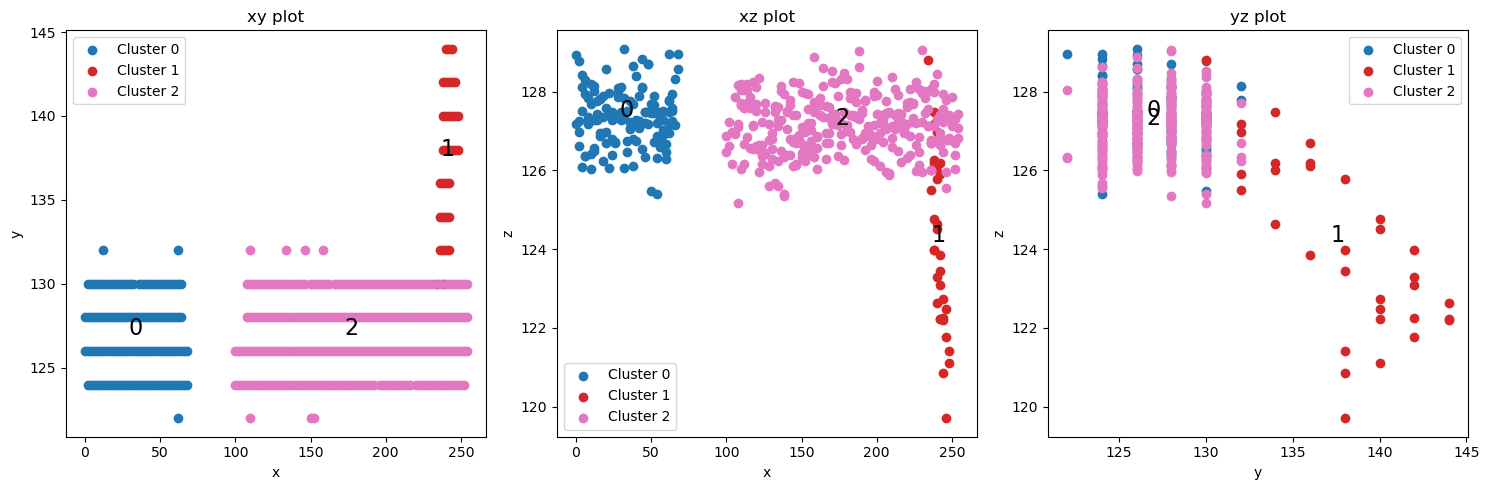

In [29]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('event_8.npy')

# Extract columns
cluster_ids = data[:, 0].astype(int)
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

# Get unique clusters
unique_clusters = np.unique(cluster_ids)

# Set up the plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Create a colormap for clusters (use the colormap name without the length argument)
colors = plt.colormaps.get_cmap('tab10')

# Scatter plots for each subplot (xy, xz, yz)
for idx, cluster in enumerate(unique_clusters):
    # Mask for the current cluster
    cluster_mask = cluster_ids == cluster
    
    # Get points belonging to the current cluster
    x_cluster = x[cluster_mask]
    y_cluster = y[cluster_mask]
    z_cluster = z[cluster_mask]
    
    # Plot xy
    axes[0].scatter(x_cluster, y_cluster, color=colors(idx / len(unique_clusters)), label=f'Cluster {cluster}')
    
    # Plot xz
    axes[1].scatter(x_cluster, z_cluster, color=colors(idx / len(unique_clusters)), label=f'Cluster {cluster}')
    
    # Plot yz
    axes[2].scatter(y_cluster, z_cluster, color=colors(idx / len(unique_clusters)), label=f'Cluster {cluster}')
    
    # Calculate cluster means
    mean_x = np.mean(x_cluster)
    mean_y = np.mean(y_cluster)
    mean_z = np.mean(z_cluster)
    
    # Plot cluster ID near the mean points
    axes[0].text(mean_x, mean_y, f'{cluster}', fontsize=16, ha='center')
    axes[1].text(mean_x, mean_z, f'{cluster}', fontsize=16, ha='center')
    axes[2].text(mean_y, mean_z, f'{cluster}', fontsize=16, ha='center')

# Set titles and labels
axes[0].set_title('xy plot')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].set_title('xz plot')
axes[1].set_xlabel('x')
axes[1].set_ylabel('z')

axes[2].set_title('yz plot')
axes[2].set_xlabel('y')
axes[2].set_ylabel('z')

# Add legends
for ax in axes:
    ax.legend()

# Display the plots
plt.tight_layout()
plt.show()


Pair (0, 2):
  Average Mahalanobis distance: 3.599
  Average Euclidean distance: 143.577
  Chi Square: 0.835
  p-value (Mahalanobis): 0.165
Pair (1, 2):
  Average Mahalanobis distance: 6.874
  Average Euclidean distance: 64.700
  Chi Square: 0.968
  p-value (Mahalanobis): 0.032
Pair (1, 0):
  Average Mahalanobis distance: 12.680
  Average Euclidean distance: 207.508
  Chi Square: 0.998
  p-value (Mahalanobis): 0.002


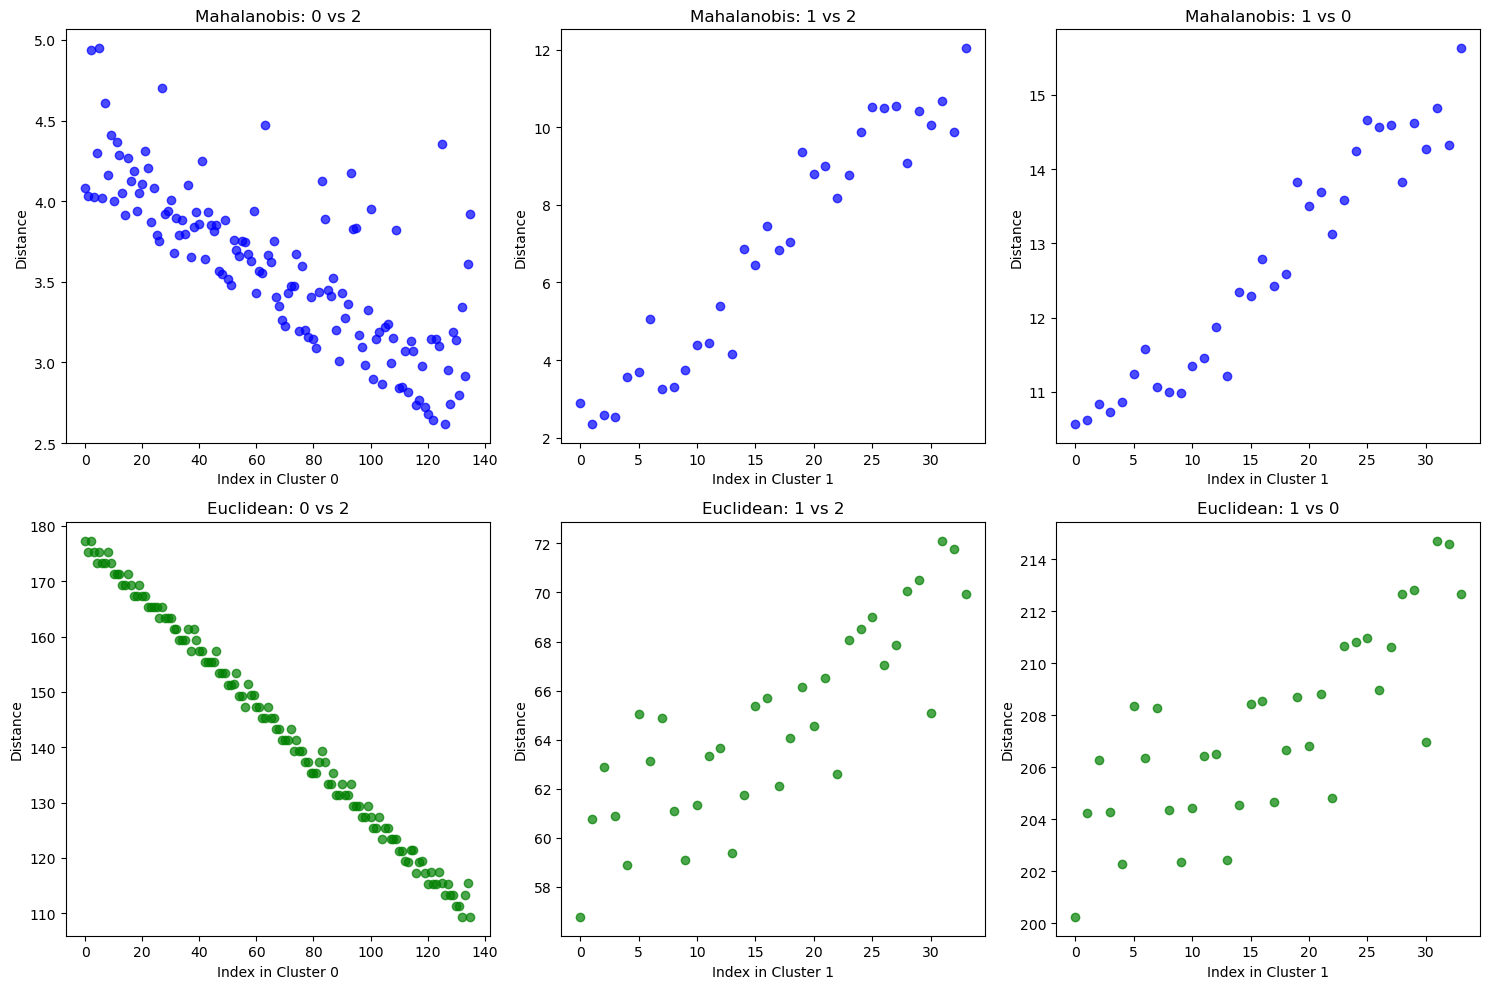

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Load the data from the .npy file
data = np.load('event_8.npy')

# Extract columns for clusters, x, y, z
clusters = data[:, 0]   # cluster labels
xyz_data = data[:, 1:4]  # [x, y, z] coordinates

# Define the pairs of clusters to analyze
pairs = [(0, 2), (1, 2), (1, 0)]

# Prepare the figure for the plots with a 2x3 grid (for 3 pairs)
plt.figure(figsize=(15, 10))

for idx, (cluster_a, cluster_b) in enumerate(pairs, start=1):
    # Get the data points for the clusters
    cluster_a_data = xyz_data[clusters == cluster_a]
    cluster_b_data = xyz_data[clusters == cluster_b]

    # Check if cluster_b_data has enough unique points
    if cluster_b_data.shape[0] < 2:
        print(f'Skipping pair ({cluster_a}, {cluster_b}) due to insufficient data in cluster {cluster_b}.')
        continue

    # Calculate the mean vector for the reference cluster (cluster B)
    mean_b = np.mean(cluster_b_data, axis=0)

    # Calculate the covariance matrix for cluster B 
    cov_matrix = np.cov(cluster_b_data.T) 
    inv_cov_matrix = np.linalg.inv(cov_matrix)

    # Calculate the Mahalanobis distances for points in cluster A against the mean of cluster B
    mahalanobis_distances = []
    for point in cluster_a_data:
        diff = point - mean_b
        mahalanobis_distance = np.sqrt(diff @ inv_cov_matrix @ diff.T)
        mahalanobis_distances.append(mahalanobis_distance)

    # Calculate the Euclidean distances for points in cluster A against the mean of cluster B
    euclidean_distances = []
    for point in cluster_a_data:
        diff = point - mean_b
        euclidean_distance = np.sqrt(diff @ diff.T)
        euclidean_distances.append(euclidean_distance)


    # Print the averages and p-values
    avg_mahalanobis = np.mean(mahalanobis_distances)
    avg_euclidean = np.mean(euclidean_distances)
    # Calculate and print the p-values for Mahalanobis distances
    dof = 2  # Degrees of freedom (3 dimensions: x, y, z)
    p_value = 1 - chi2.cdf(avg_mahalanobis, df=dof)  # Survival function (1 - CDF)
    avg_p_value = p_value
    
    print(f'Pair ({cluster_a}, {cluster_b}):')
    print(f'  Average Mahalanobis distance: {avg_mahalanobis:.3f}')
    print(f'  Average Euclidean distance: {avg_euclidean:.3f}')
    print(f'  Chi Square: {chi2.cdf(avg_mahalanobis, df=dof) :.3f}')
    print(f'  p-value (Mahalanobis): {avg_p_value:.3f}')

    # Plotting Mahalanobis Distance
    plt.subplot(2, 3, idx)
    plt.scatter(range(len(mahalanobis_distances)), mahalanobis_distances, color='blue', alpha=0.7)
    plt.title(f'Mahalanobis: {cluster_a} vs {cluster_b}')
    plt.xlabel(f'Index in Cluster {cluster_a}')
    plt.ylabel('Distance')

    # Plotting Euclidean Distance
    plt.subplot(2, 3, idx + 3)
    plt.scatter(range(len(euclidean_distances)), euclidean_distances, color='green', alpha=0.7)
    plt.title(f'Euclidean: {cluster_a} vs {cluster_b}')
    plt.xlabel(f'Index in Cluster {cluster_a}')
    plt.ylabel('Distance')

# Show the plot
plt.tight_layout()
plt.show()

<u>**Continue reading**</u>

Notice how, points in cluster 0 has more than 16 % chance of belonging to cluster 2, while points in cluster 1 (the scattered track) has only around 3% chance of belonging to the cluster 2 (the beam track)

Now lets look at another event 25MeV and 1CM, low angled track 

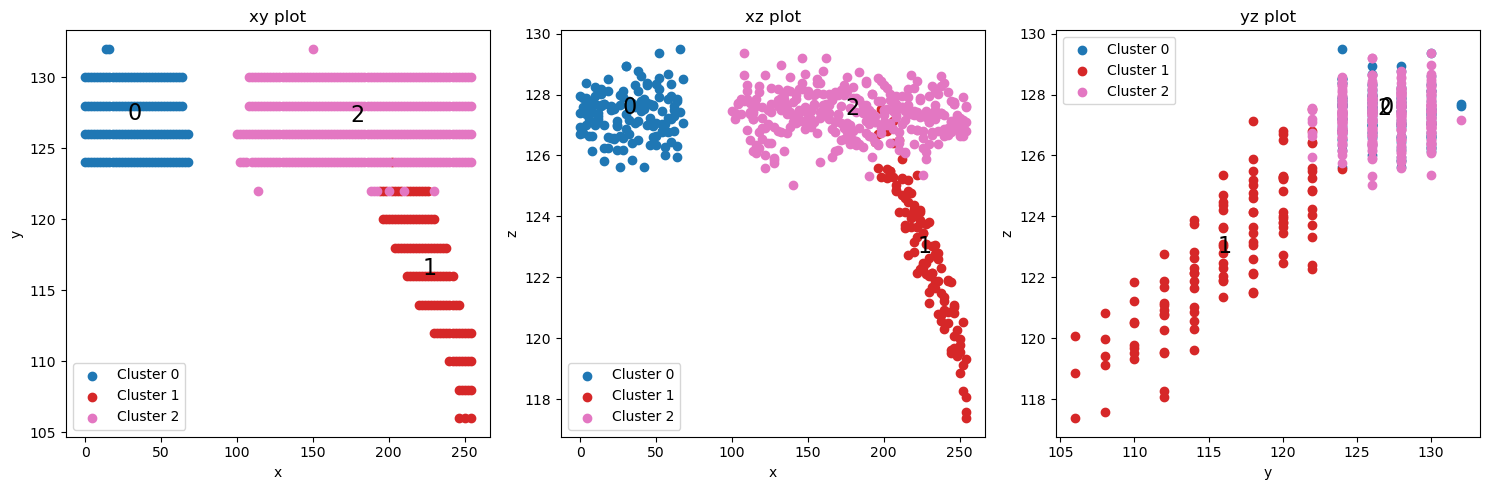

In [30]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('event_9.npy')

# Extract columns
cluster_ids = data[:, 0].astype(int)
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

# Get unique clusters
unique_clusters = np.unique(cluster_ids)

# Set up the plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Create a colormap for clusters (use the colormap name without the length argument)
colors = plt.colormaps.get_cmap('tab10')

# Scatter plots for each subplot (xy, xz, yz)
for idx, cluster in enumerate(unique_clusters):
    # Mask for the current cluster
    cluster_mask = cluster_ids == cluster
    
    # Get points belonging to the current cluster
    x_cluster = x[cluster_mask]
    y_cluster = y[cluster_mask]
    z_cluster = z[cluster_mask]
    
    # Plot xy
    axes[0].scatter(x_cluster, y_cluster, color=colors(idx / len(unique_clusters)), label=f'Cluster {cluster}')
    
    # Plot xz
    axes[1].scatter(x_cluster, z_cluster, color=colors(idx / len(unique_clusters)), label=f'Cluster {cluster}')
    
    # Plot yz
    axes[2].scatter(y_cluster, z_cluster, color=colors(idx / len(unique_clusters)), label=f'Cluster {cluster}')
    
    # Calculate cluster means
    mean_x = np.mean(x_cluster)
    mean_y = np.mean(y_cluster)
    mean_z = np.mean(z_cluster)
    
    # Plot cluster ID near the mean points
    axes[0].text(mean_x, mean_y, f'{cluster}', fontsize=16, ha='center')
    axes[1].text(mean_x, mean_z, f'{cluster}', fontsize=16, ha='center')
    axes[2].text(mean_y, mean_z, f'{cluster}', fontsize=16, ha='center')

# Set titles and labels
axes[0].set_title('xy plot')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].set_title('xz plot')
axes[1].set_xlabel('x')
axes[1].set_ylabel('z')

axes[2].set_title('yz plot')
axes[2].set_xlabel('y')
axes[2].set_ylabel('z')

# Add legends
for ax in axes:
    ax.legend()

# Display the plots
plt.tight_layout()
plt.show()


Pair (0, 2):
  Average Mahalanobis distance: 3.676
  Average Euclidean distance: 146.747
  Chi Square: 0.841
  p-value (Mahalanobis): 0.159
Pair (1, 2):
  Average Mahalanobis distance: 7.653
  Average Euclidean distance: 48.944
  Chi Square: 0.978
  p-value (Mahalanobis): 0.022
Pair (1, 0):
  Average Mahalanobis distance: 12.834
  Average Euclidean distance: 194.574
  Chi Square: 0.998
  p-value (Mahalanobis): 0.002


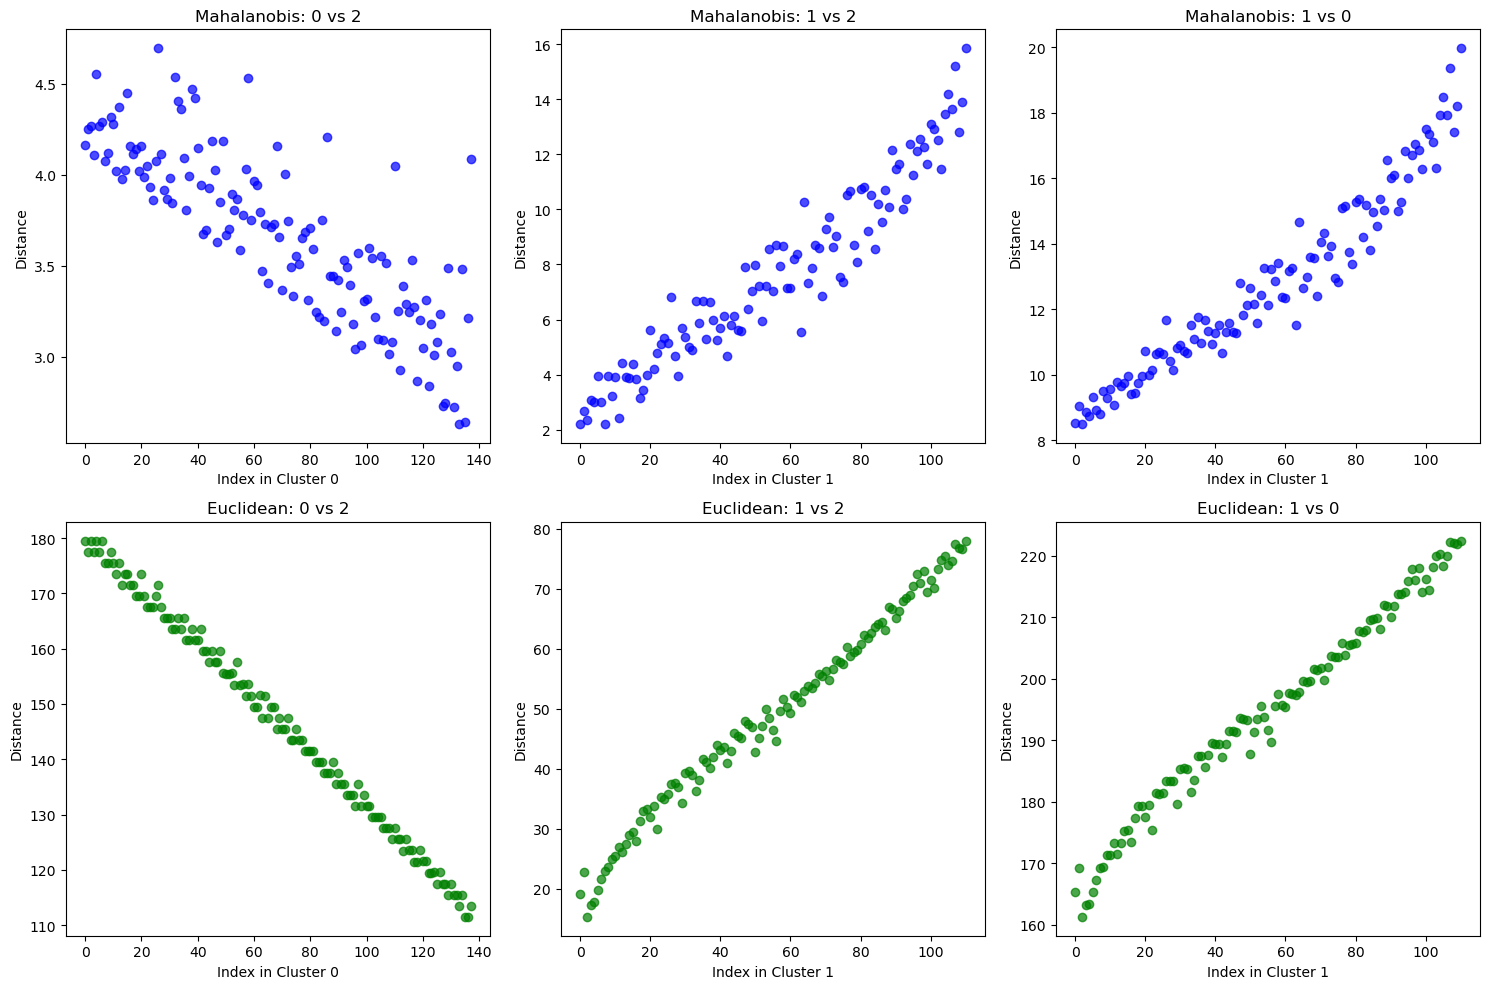

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# Load the data from the .npy file
data = np.load('event_9.npy')

# Extract columns for clusters, x, y, z
clusters = data[:, 0]   # cluster labels
xyz_data = data[:, 1:4]  # [x, y, z] coordinates

# Define the pairs of clusters to analyze
pairs = [(0, 2), (1, 2), (1, 0)]

# Prepare the figure for the plots with a 2x3 grid (for 3 pairs)
plt.figure(figsize=(15, 10))

for idx, (cluster_a, cluster_b) in enumerate(pairs, start=1):
    # Get the data points for the clusters
    cluster_a_data = xyz_data[clusters == cluster_a]
    cluster_b_data = xyz_data[clusters == cluster_b]

    # Check if cluster_b_data has enough unique points
    if cluster_b_data.shape[0] < 2:
        print(f'Skipping pair ({cluster_a}, {cluster_b}) due to insufficient data in cluster {cluster_b}.')
        continue

    # Calculate the mean vector for the reference cluster (cluster B)
    mean_b = np.mean(cluster_b_data, axis=0)

    # Calculate the covariance matrix for cluster B 
    cov_matrix = np.cov(cluster_b_data.T) 
    inv_cov_matrix = np.linalg.inv(cov_matrix)

    # Calculate the Mahalanobis distances for points in cluster A against the mean of cluster B
    mahalanobis_distances = []
    for point in cluster_a_data:
        diff = point - mean_b
        mahalanobis_distance = np.sqrt(diff @ inv_cov_matrix @ diff.T)
        mahalanobis_distances.append(mahalanobis_distance)

    # Calculate the Euclidean distances for points in cluster A against the mean of cluster B
    euclidean_distances = []
    for point in cluster_a_data:
        diff = point - mean_b
        euclidean_distance = np.sqrt(diff @ diff.T)
        euclidean_distances.append(euclidean_distance)


    # Print the averages and p-values
    avg_mahalanobis = np.mean(mahalanobis_distances)
    avg_euclidean = np.mean(euclidean_distances)
    # Calculate and print the p-values for Mahalanobis distances
    dof = 2  # Degrees of freedom (3 dimensions: x, y, z)
    p_value = 1 - chi2.cdf(avg_mahalanobis, df=dof)  # Survival function (1 - CDF)
    avg_p_value = p_value
    
    print(f'Pair ({cluster_a}, {cluster_b}):')
    print(f'  Average Mahalanobis distance: {avg_mahalanobis:.3f}')
    print(f'  Average Euclidean distance: {avg_euclidean:.3f}')
    print(f'  Chi Square: {chi2.cdf(avg_mahalanobis, df=dof) :.3f}')
    print(f'  p-value (Mahalanobis): {avg_p_value:.3f}')

    # Plotting Mahalanobis Distance
    plt.subplot(2, 3, idx)
    plt.scatter(range(len(mahalanobis_distances)), mahalanobis_distances, color='blue', alpha=0.7)
    plt.title(f'Mahalanobis: {cluster_a} vs {cluster_b}')
    plt.xlabel(f'Index in Cluster {cluster_a}')
    plt.ylabel('Distance')

    # Plotting Euclidean Distance
    plt.subplot(2, 3, idx + 3)
    plt.scatter(range(len(euclidean_distances)), euclidean_distances, color='green', alpha=0.7)
    plt.title(f'Euclidean: {cluster_a} vs {cluster_b}')
    plt.xlabel(f'Index in Cluster {cluster_a}')
    plt.ylabel('Distance')

# Show the plot
plt.tight_layout()
plt.show()

<u>**Continue reading**</u>

Notice how, points in cluster 0 has more than 15 % chance of belonging to cluster 2, while points in cluster 1 (the scattered track) has only around 2% chance of belonging to the cluster 2 (the beam track)

